In [1]:
#Res unet 3d

In [2]:
# --- Standard Python Utilities ---
import os
import glob
import random
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# --- Visualization & Image Processing ---
import matplotlib.pyplot as plt
from PIL import Image
import nibabel as nib
from skimage.io import imread, imshow, concatenate_images
from skimage.transform import resize

# --- Scikit-Learn Utilities ---
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import class_weight

# --- TensorFlow & Keras Core ---
import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras import metrics
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# --- Keras Callbacks ---
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger

# --- Keras Layers (Flattened API) ---
from tensorflow.keras.layers import (
    Input, 
    BatchNormalization, 
    Activation, 
    Dense, 
    Dropout, 
    Maximum, 
    PReLU,
    Lambda, 
    RepeatVector, 
    Reshape,
    Conv2D, 
    Conv2DTranspose, 
    Conv3D, 
    Conv3DTranspose,
    MaxPooling2D, 
    GlobalMaxPool2D, 
    MaxPooling3D,
    concatenate, 
    Add  # Note: Capitalized 'Add' is the correct functional layer for your V-Net residual connections
)

# Inline plotting for Jupyter/Kaggle notebook environments
%matplotlib inline

print("TensorFlow Version:", tf.__version__)
print("All modules imported successfully without errors!")

2026-05-17 05:07:56.643261: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778994477.030635      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778994477.125709      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778994478.004021      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778994478.004055      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778994478.004057      57 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0
All modules imported successfully without errors!


In [3]:
train_img_dir = "/kaggle/input/brats701515/input_data_128/train/images/"
train_mask_dir = "/kaggle/input/brats701515/input_data_128/train/masks/"

train_img_list = sorted(os.listdir(train_img_dir))
train_mask_list =  sorted(os.listdir(train_mask_dir))


In [4]:
batch_size = 2
# print(train_img_list,train_mask_list)

In [5]:
def load_img(img_dir , img_list):
    
    images = []
    for i,image_name in enumerate(img_list):
        
        if(image_name.split('.')[1]=='npy'):
            # if the file is numpy array
            
            image = np.load(img_dir + image_name)
            images.append(image)
        
    images = np.array(images)
        
    return (images)

In [6]:
def imageLoader(img_dir , img_list , mask_dir , mask_list , batch_size):
    
    L = len(img_list)
    
    while True:
        
        batch_start = 0
        batch_end = batch_size
        
        while batch_start < L:
            
            limit = min(batch_end , L)
            
            X = load_img(img_dir , img_list[batch_start:limit]) # load image
            Y = load_img(mask_dir , mask_list[batch_start:limit]) # load mask
            
            yield(X,Y) # yeilds images - a tuple with 2 numpy arrays with batch_size samples
            
            batch_start += batch_size
            batch_end += batch_size

In [7]:
train_img_datagen = imageLoader(train_img_dir, train_img_list,  train_mask_dir, train_mask_list, batch_size)

In [8]:
img, msk = train_img_datagen.__next__()

In [9]:
img.shape

(2, 128, 128, 128, 3)

In [10]:
msk.shape

(2, 128, 128, 128, 4)

In [11]:
img_num = random.randint(0,img.shape[0]-1)
test_img=img[img_num]
test_mask=msk[img_num]
test_mask=np.argmax(test_mask, axis=3)

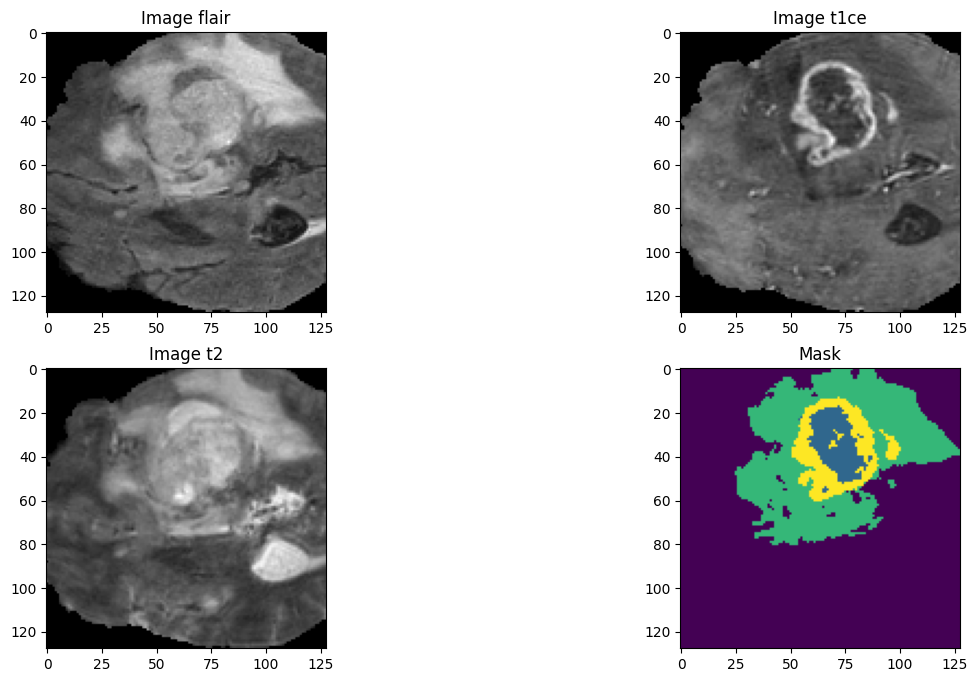

In [12]:
n_slice=random.randint(0, test_mask.shape[2])
n_slice=55
plt.figure(figsize=(15, 8))


plt.subplot(221)
plt.imshow(test_img[:,:,n_slice, 0], cmap='gray')
plt.title('Image flair')
plt.subplot(222)
plt.imshow(test_img[:,:,n_slice, 1], cmap='gray')
plt.title('Image t1ce')
plt.subplot(223)
plt.imshow(test_img[:,:,n_slice, 2], cmap='gray')
plt.title('Image t2')
plt.subplot(224)
plt.imshow(test_mask[:,:,n_slice])
plt.title('Mask')
plt.show()

In [13]:
# 1. Dice Coefficient
def dice_coefficient(y_true, y_pred, smooth=1e-5):
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

# 2. Intersection over Union (IoU)
def iou_coefficient(y_true, y_pred, smooth=1e-5):
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# 3. Precision (Positive Predictive Value)
def precision_metric(y_true, y_pred, smooth=1e-5):
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (intersection + smooth) / (tf.reduce_sum(y_pred_f) + smooth)

# 4. Sensitivity (Recall / True Positive Rate)
def recall_metric(y_true, y_pred, smooth=1e-5):
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (intersection + smooth) / (tf.reduce_sum(y_true_f) + smooth)

# 5. Specificity (True Negative Rate)
def specificity_metric(y_true, y_pred, smooth=1e-5):
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    true_negatives = tf.reduce_sum((1.0 - y_true_f) * (1.0 - y_pred_f))
    actual_negatives = tf.reduce_sum(1.0 - y_true_f)
    return (true_negatives + smooth) / (actual_negatives + smooth)

# Multi-Class Dice Loss Objective
def multi_class_dice_loss(y_true, y_pred, num_classes=4):
    loss = 0.0
    y_true = tf.cast(y_true, tf.float32)
    for i in range(num_classes):
        loss += (1.0 - dice_coefficient(y_true[..., i], y_pred[..., i]))
    return loss / num_classes

print("Cell 4: Evaluation dashboard and target loss compiled natively.")

Cell 4: Evaluation dashboard and target loss compiled natively.


In [14]:
import tensorflow as tf

def thresholded_iou_score(y_true, y_pred, threshold=0.5, smooth=1e-5):
    """
    Native replacement for sm.metrics.IOUScore(threshold=0.5).
    Binarizes predictions at the threshold before calculating overlap.
    """
    y_true = tf.cast(y_true, tf.float32)
    # Apply the 0.5 threshold to the predictions
    y_pred_thresholded = tf.cast(y_pred > threshold, tf.float32)
    
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred_thresholded, [-1])
    
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)


class CleanMeanIoU(tf.keras.metrics.Metric):
    """
    Safe wrapper for tf.keras.metrics.MeanIoU(num_classes=4).
    Converts 4-channel one-hot masks into categorical integers to avoid dimension crashes.
    """
    def __init__(self, num_classes=4, name='mean_iou', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.iou_metric = tf.keras.metrics.MeanIoU(num_classes=num_classes)
        
    def update_state(self, y_true, y_pred, sample_weight=None):
        # Convert one-hot probabilities [batch, H, W, D, 4] into class labels [batch, H, W, D]
        y_true_argmax = tf.argmax(y_true, axis=-1)
        y_pred_argmax = tf.argmax(y_pred, axis=-1)
        self.iou_metric.update_state(y_true_argmax, y_pred_argmax, sample_weight)
        
    def result(self):
        return self.iou_metric.result()
        
    def reset_state(self):
        self.iou_metric.reset_state()

In [15]:
def residual_conv_block(input_tensor, num_filters):
    """3D Residual unit using 1x1x1 projections to match channel dimensions."""
    x = Conv3D(num_filters, kernel_size=(3, 3, 3), padding='same', kernel_initializer='he_normal')(input_tensor)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv3D(num_filters, kernel_size=(3, 3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    
    # Direct projection mapping to resolve channel shape changes
    shortcut = Conv3D(num_filters, kernel_size=(1, 1, 1), padding='same')(input_tensor)
    shortcut = BatchNormalization()(shortcut)
    
    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x

def res_unet_3d(IMG_HEIGHT, IMG_WIDTH, IMG_DEPTH, IMG_CHANNELS, n_filters=16, dropout=0.2):
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_DEPTH, IMG_CHANNELS))
    
    # --- ENCODER PATHWAY ---
    c1 = residual_conv_block(inputs, n_filters)
    p1 = MaxPool3D(pool_size=(2, 2, 2))(c1)
    
    c2 = residual_conv_block(p1, n_filters*2)
    p2 = MaxPool3D(pool_size=(2, 2, 2))(c2)
    
    c3 = residual_conv_block(p2, n_filters*4)
    p3 = MaxPool3D(pool_size=(2, 2, 2))(c3)
    p3 = Dropout(dropout)(p3)
    
    c4 = residual_conv_block(p3, n_filters*8)
    p4 = MaxPool3D(pool_size=(2, 2, 2))(c4)
    p4 = Dropout(dropout)(p4)
    
    # --- BOTTLENECK ---
    bn = residual_conv_block(p4, n_filters*16)
    bn = Dropout(dropout)(bn)
    
    # --- DECODER PATHWAY ---
    u6 = Conv3DTranspose(n_filters*8, kernel_size=(2, 2, 2), strides=(2, 2, 2), padding='same')(bn)
    u6 = concatenate([u6, c4])
    c6 = residual_conv_block(u6, n_filters*8)
    
    u7 = Conv3DTranspose(n_filters*4, kernel_size=(2, 2, 2), strides=(2, 2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = residual_conv_block(u7, n_filters*4)
    
    u8 = Conv3DTranspose(n_filters*2, kernel_size=(2, 2, 2), strides=(2, 2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = residual_conv_block(u8, n_filters*2)
    
    u9 = Conv3DTranspose(n_filters, kernel_size=(2, 2, 2), strides=(2, 2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1])
    c9 = residual_conv_block(u9, n_filters)
    
    # Multi-Class Softmax Output (4 output zones)
    outputs = Conv3D(4, kernel_size=(1, 1, 1), activation='softmax')(c9)
    
    model = Model(inputs=[inputs], outputs=[outputs])
    return model

print("Cell 5: ResUNet3D blueprint mapped.")

Cell 5: ResUNet3D blueprint mapped.


In [16]:
# Run this cell to explicitly define MaxPool3D in your notebook
from tensorflow.keras.layers import MaxPool3D

# Now re-run your model initialization
model = res_unet_3d(128, 128, 128, 3, n_filters=16)
print("Model initialized successfully on your P100 GPU!")

I0000 00:00:1778994515.381097      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model initialized successfully on your P100 GPU!


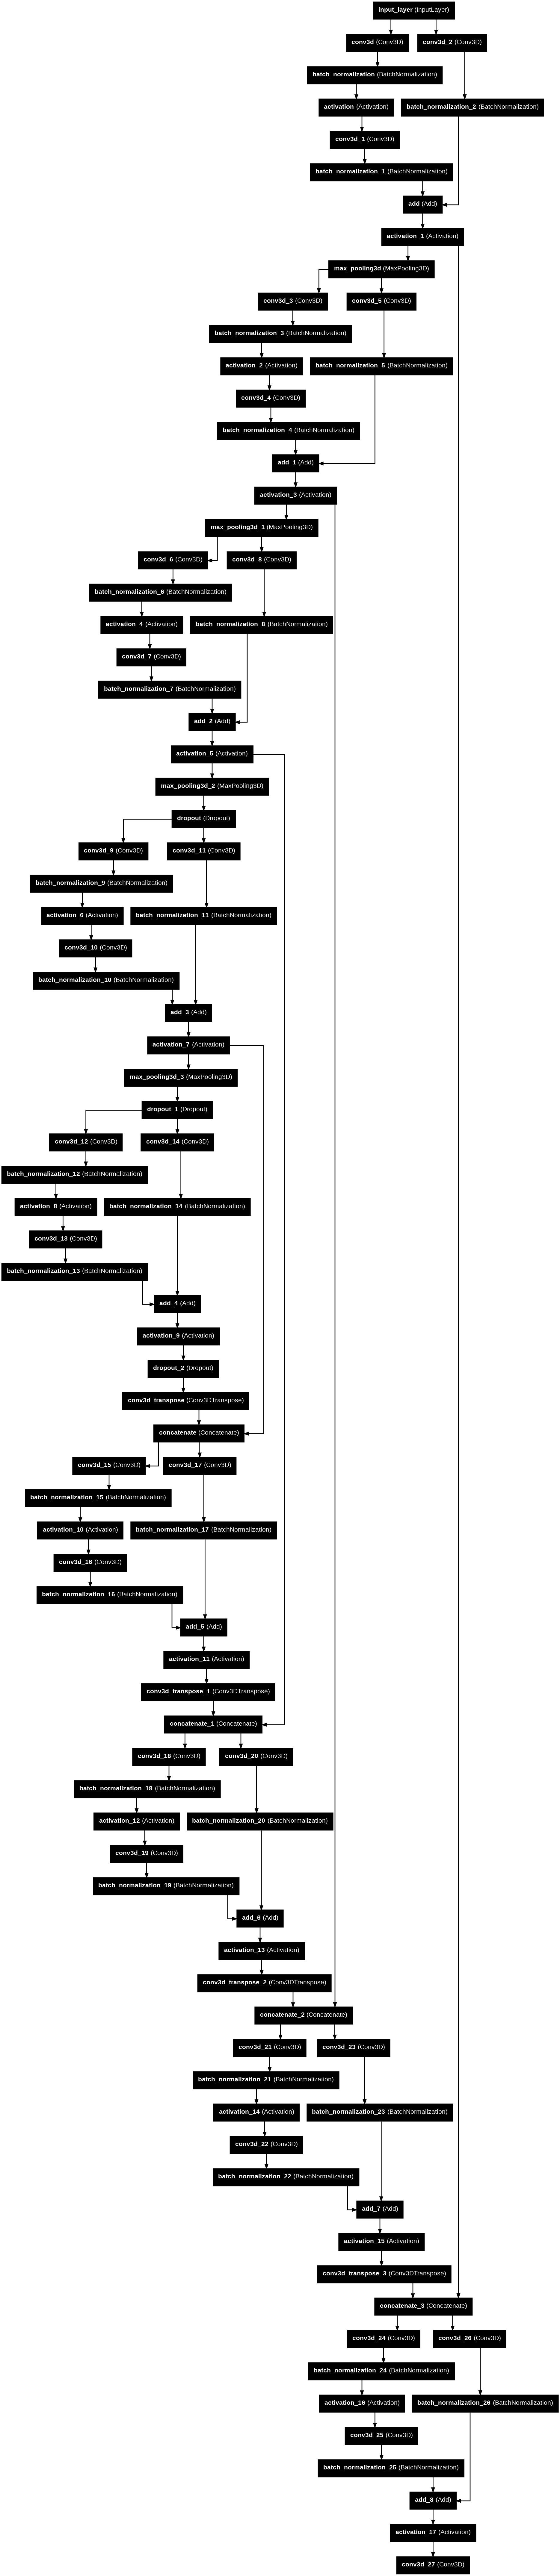

In [17]:
 #prining the model as image 

 from tensorflow.keras.utils import plot_model
 tf.keras.utils.plot_model(
     model,
     to_file="model.png",
     show_shapes=False,
     show_dtype=False,
     show_layer_names=True,
     rankdir="TB",
     expand_nested=False,
     dpi=96,
     layer_range=None,
     show_layer_activations=False,
)

In [18]:
print(model.input_shape)
print(model.output_shape)

(None, 128, 128, 128, 3)
(None, 128, 128, 128, 4)


In [19]:
img_list = sorted(os.listdir(train_img_dir))
print(len(img_list))
msk_list = sorted(os.listdir(train_mask_dir))
print(len(msk_list))


240
240


In [20]:
num_images = len(os.listdir(train_img_dir))

In [21]:
img_num = random.randint(0,num_images-1)
test_img = np.load(train_img_dir+img_list[img_num])
test_mask = np.load(train_mask_dir+msk_list[img_num])
test_mask = np.argmax(test_mask, axis=3)

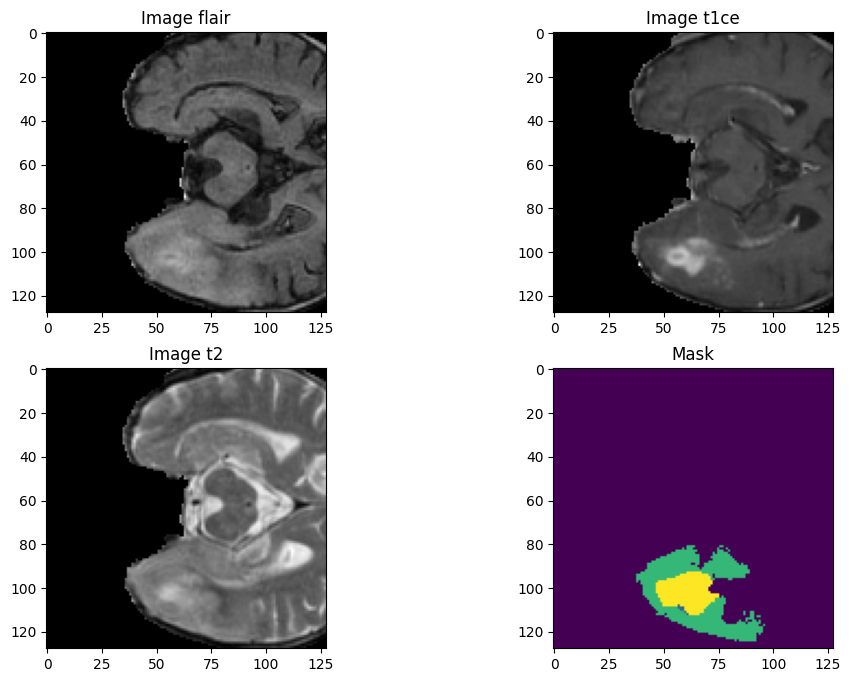

In [22]:
# n_slice=random.randint(0, test_mask.shape[2])
n_slice = 55
plt.figure(figsize=(12, 8))

plt.subplot(221)
plt.imshow(test_img[:,:,n_slice, 0], cmap='gray')
plt.title('Image flair')
plt.subplot(222)
plt.imshow(test_img[:,:,n_slice, 1], cmap='gray')
plt.title('Image t1ce')
plt.subplot(223)
plt.imshow(test_img[:,:,n_slice, 2], cmap='gray')
plt.title('Image t2')
plt.subplot(224)
plt.imshow(test_mask[:,:,n_slice])
plt.title('Mask')
plt.show()

In [23]:
val_img_dir = "/kaggle/input/brats701515/input_data_128/val/images/"
val_mask_dir = "/kaggle/input/brats701515/input_data_128/val/masks/"

train_img_list = sorted(os.listdir(train_img_dir))
train_mask_list = sorted(os.listdir(train_mask_dir))

val_img_list = sorted(os.listdir(val_img_dir))
val_mask_list = sorted(os.listdir(val_mask_dir))
print(len(os.listdir(val_img_dir)))
print(len(os.listdir(val_mask_dir)))

51
51


Image Agumentation for 3D Images

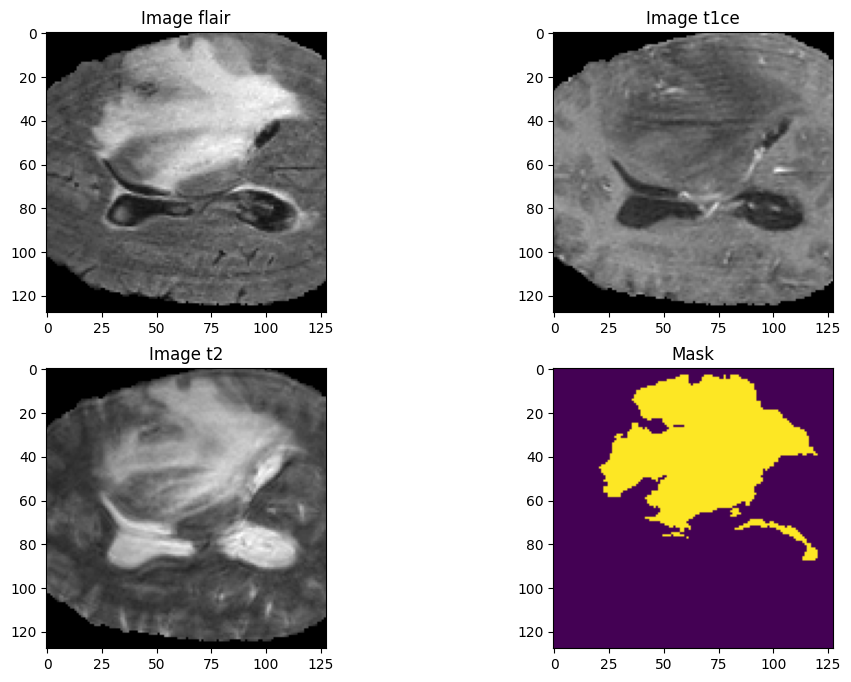

In [24]:
image='/kaggle/input/brats701515/input_data_128/train/images/image_0.npy'
mask ='/kaggle/input/brats701515/input_data_128/train/masks/mask_0.npy'

img_num = random.randint(0,num_images-1)
test_img = np.load(image)
test_mask = np.load(mask)
test_mask = np.argmax(test_mask, axis=3)



n_slice=random.randint(0, test_mask.shape[2])
plt.figure(figsize=(12, 8))

plt.subplot(221)
plt.imshow(test_img[:,:,n_slice, 0], cmap='gray')
plt.title('Image flair')
plt.subplot(222)
plt.imshow(test_img[:,:,n_slice, 1], cmap='gray')
plt.title('Image t1ce')
plt.subplot(223)
plt.imshow(test_img[:,:,n_slice, 2], cmap='gray')
plt.title('Image t2')
plt.subplot(224)
plt.imshow(test_mask[:,:,n_slice])
plt.title('Mask')
plt.show()

In [25]:
batch_size=2
train_img_datagen = imageLoader(train_img_dir, train_img_list,  train_mask_dir, train_mask_list, batch_size)
val_img_datagen = imageLoader(val_img_dir, val_img_list, val_mask_dir, val_mask_list, batch_size)

In [26]:
img, msk = train_img_datagen.__next__() 
img.shape
msk.shape

(2, 128, 128, 128, 4)

In [27]:
steps_per_epoch = (len(train_img_list)//batch_size )+1
val_steps_per_epoch =( len(val_img_list)//batch_size )+1 

Defining the loss function and the optimizer function

In [28]:
# 1. Initialize the architectural blueprint
model = res_unet_3d(128, 128, 128, 3, n_filters=16)

# 2. Configure Automated Checkpoint Tracking
checkpoint = ModelCheckpoint(
    filepath='best_resunet3d_model.keras',   # Preserved natively in /kaggle/working/
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

callbacks_list = [checkpoint, early_stopping, lr_reducer]

# 3. Model Compilation with your 6-metric dashboard
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=multi_class_dice_loss,
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name='accuracy'), # Pixel Accuracy
        dice_coefficient,
        iou_coefficient,
        precision_metric,
        recall_metric,
        specificity_metric
    ]
)

print("Cell 6: ResUNet3D successfully compiled and armed for training!")

Cell 6: ResUNet3D successfully compiled and armed for training!


In [29]:
# Re-compile your ResUNet3D model with the expanded 8-metric suite
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=multi_class_dice_loss,
    metrics=[
        # 1. Pixel Accuracy
        tf.keras.metrics.CategoricalAccuracy(name='accuracy'), 
        
        # 2. Your Requested Mean IoU (Multi-Class)
        CleanMeanIoU(num_classes=4, name='mean_iou'), 
        
        # 3. Your Requested Thresholded IoU (Hard Overlap)
        thresholded_iou_score, 
        
        # 4. Standard Continuous Metrics
        dice_coefficient,
        iou_coefficient,
        precision_metric,
        recall_metric,
        specificity_metric
    ]
)

print("ResUNet3D successfully compiled! Ready to track your customized evaluation dashboard.")

ResUNet3D successfully compiled! Ready to track your customized evaluation dashboard.


In [30]:
# Compute tracking batch constraints
steps_per_epoch = len(train_img_list) // batch_size
val_steps_per_epoch = len(val_img_list) // batch_size

# Start training loop
history = model.fit(
    train_img_datagen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_img_datagen,
    validation_steps=val_steps_per_epoch,
    epochs=40,
    callbacks=callbacks_list
)

Epoch 1/40


I0000 00:00:1778994540.261755     132 service.cc:152] XLA service 0x7fe0840058c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778994540.261804     132 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778994543.472087     132 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-17 05:09:06.012177: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-17 05:09:06.238138: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-17 05:09:06.715951: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accur

120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3710 - dice_coefficient: 0.3359 - iou_coefficient: 0.2054 - loss: 0.8249 - mean_iou: 0.1341 - precision_metric: 0.3359 - recall_metric: 0.3359 - specificity_metric: 0.7786 - thresholded_iou_score: 0.1960
Epoch 1: val_loss improved from inf to 0.83121, saving model to best_resunet3d_model.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 221s 1s/step - accuracy: 0.3715 - dice_coefficient: 0.3364 - iou_coefficient: 0.2057 - loss: 0.8246 - mean_iou: 0.1344 - precision_metric: 0.3364 - recall_metric: 0.3364 - specificity_metric: 0.7788 - thresholded_iou_score: 0.1965 - val_accuracy: 0.4133 - val_dice_coefficient: 0.3140 - val_iou_coefficient: 0.1865 - val_loss: 0.8312 - val_mean_iou: 0.1485 - val_precision_metric: 0.3140 - val_recall_metric: 0.3140 - val_specificity_metric: 0.7713 - val_thresholded_iou_score: 0.2194 - learning_rate: 1.0000e-04
Epoch 2/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4364 - dice_coefficient: 0.4245 - iou_coeffi

2026-05-17 05:16:40.215065: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-17 05:16:40.422433: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-17 05:16:40.771645: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-17 05:16:40.984752: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-17 05:16:41.610589: E external/local_xla/xla/stream_


Epoch 3: val_loss improved from 0.74730 to 0.64196, saving model to best_resunet3d_model.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.4317 - dice_coefficient: 0.4198 - iou_coefficient: 0.2660 - loss: 0.6187 - mean_iou: 0.3232 - precision_metric: 0.4198 - recall_metric: 0.4198 - specificity_metric: 0.8066 - thresholded_iou_score: 0.2754 - val_accuracy: 0.4372 - val_dice_coefficient: 0.4096 - val_iou_coefficient: 0.2579 - val_loss: 0.6420 - val_mean_iou: 0.2992 - val_precision_metric: 0.4096 - val_recall_metric: 0.4096 - val_specificity_metric: 0.8032 - val_thresholded_iou_score: 0.2806 - learning_rate: 1.0000e-04
Epoch 4/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4341 - dice_coefficient: 0.4264 - iou_coefficient: 0.2714 - loss: 0.5801 - mean_iou: 0.3441 - precision_metric: 0.4264 - recall_metric: 0.4264 - specificity_metric: 0.8088 - thresholded_iou_score: 0.2776
Epoch 4: val_loss improved from 0.64196 to 0.61251, saving model to best_resunet3d_model.kera

In [31]:
# Save only the weights
model.save_weights('resunet3d_weights.weights.h5')

print("Weights successfully saved as 'resunet3d_weights.weights.h5'")

Weights successfully saved as 'resunet3d_weights.weights.h5'


In [32]:
test_img_dir = "/kaggle/input/brats701515/input_data_128/test/images/"
test_mask_dir = "/kaggle/input/brats701515/input_data_128/test/masks/"

test_img_list = sorted(os.listdir(test_img_dir))
test_mask_list = sorted(os.listdir(test_mask_dir))

batch_size=2
test_img_datagen = imageLoader(test_img_dir, test_img_list,  test_mask_dir, test_mask_list, batch_size)
test_steps_per_epoch =(len(test_img_list)//batch_size )+1 

In [37]:
# 1. Run the evaluation and capture all outputs safely into one list
results = model.evaluate(
    test_img_datagen, 
    steps=test_steps_per_epoch, 
    verbose=1
)

# 2. Map the metric names to their calculated values in a dictionary
metrics_dict = dict(zip(model.metrics_names, results))

# --- DIAGNOSTIC PRINT ---
# This will show you exactly what internal names Keras chose for your metrics
print("\nRegistered metric keys:", list(metrics_dict.keys()))
print("="*40)

# 3. Flexible lookup to completely avoid KeyErrors
test_loss = metrics_dict.get('loss', results[0])

# Dynamically find the accuracy key (whether it's named 'accuracy' or 'categorical_accuracy')
acc_key = next((k for k in metrics_dict.keys() if 'acc' in k), None)
test_accuracy = metrics_dict[acc_key] if acc_key else 0.0

iou_score = metrics_dict.get('iou_coefficient', 0.0)
mean_iou = metrics_dict.get('mean_iou', 0.0)

# 4. Your original clean print layout
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')
print(f'Test IoU Score: {iou_score:.4f}')
print(f'Test Mean IoU: {mean_iou:.4f}')
print("="*40)

27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 389ms/step - accuracy: 0.9769 - dice_coefficient: 0.9765 - iou_coefficient: 0.9543 - loss: 0.2580 - mean_iou: 0.6497 - precision_metric: 0.9765 - recall_metric: 0.9765 - specificity_metric: 0.9922 - thresholded_iou_score: 0.9552

Registered metric keys: ['loss', 'compile_metrics']
Test Loss: 0.2589
Test Accuracy: 0.0000
Test IoU Score: 0.0000
Test Mean IoU: 0.0000


In [34]:
# 1. Capture the evaluation results as a single list
results = model.evaluate(
    test_img_datagen,      
    steps=test_steps_per_epoch,      
    verbose=1      
)

# 2. Dynamically print every metric name alongside its calculated value
print("\n=== Evaluation Results ===")
for metric_name, metric_value in zip(model.metrics_names, results):
    print(f"{metric_name}: {metric_value:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.9801 - dice_coefficient: 0.9797 - iou_coefficient: 0.9604 - loss: 0.2239 - mean_iou: 0.6795 - precision_metric: 0.9797 - recall_metric: 0.9797 - specificity_metric: 0.9932 - thresholded_iou_score: 0.9613

=== Evaluation Results ===
loss: 0.2589
compile_metrics: 0.9790


In [35]:
def dice_score(o, t, eps=1e-8):
    num = 2*(o*t).sum() + eps
    den = o.sum() + t.sum() + eps
    return num/den

def softmax_output_dice(target,output):
    ret = []
    
    # whole   wt
    o = output > 0; t = target > 0 # ce
    ret += dice_score(o, t),
    
    # core   tc
    o = (output == 1) | (output == 3)
    t = (target == 1) | (target == 3)
    ret += dice_score(o, t),
    
    # active   et
    o = (output == 3);t = (target == 3)
    ret += dice_score(o, t),

    return ret


dice_scores_wt = []
dice_scores_tc = []
dice_scores_et = []
num_classes = 4

for batch in range(test_steps_per_epoch):
    
    test_img, test_mask = next(test_img_datagen)
    test_prediction = model.predict(test_img)
    
    test_mask_argmax=np.argmax(test_mask, axis=4)[0,:,:,:]
    test_prediction_argmax=np.argmax(test_prediction, axis=4)[0,:,:,:]
    
    tensor = softmax_output_dice(test_mask_argmax, test_prediction_argmax)
    dice_batch = tensor[0]
    dice_scores_wt.append(dice_batch)
    dice_scores_tc.append(tensor[1])
    dice_scores_et.append(tensor[2])


print("Dice Scores for Unet variation 2 trained for 40 epochs with dice loss")
average_dice_score_et = sum(dice_scores_et) / len(dice_scores_et)
print("Average Dice Score et:", average_dice_score_et)
average_dice_score_wt = sum(dice_scores_wt) / len(dice_scores_wt)
print("Average Dice Score wt:", average_dice_score_wt)
average_dice_score_tc = sum(dice_scores_tc) / len(dice_scores_tc)
print("Average Dice Score tc:", average_dice_score_tc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 464

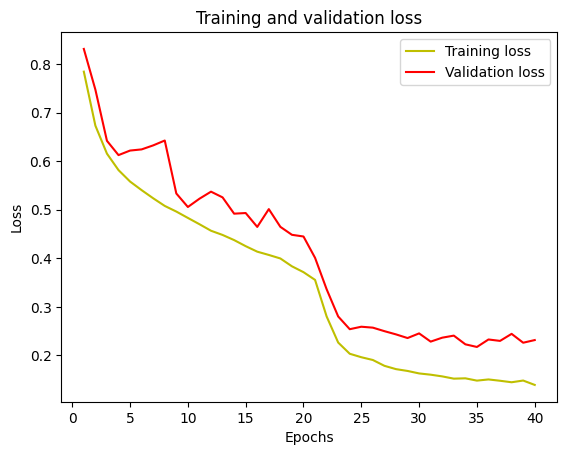

In [38]:
# metrics = ['accuracy', sm.metrics.IOUScore(threshold=0.5), mean_iou]
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [39]:
print(history.history.keys())

dict_keys(['accuracy', 'dice_coefficient', 'iou_coefficient', 'loss', 'mean_iou', 'precision_metric', 'recall_metric', 'specificity_metric', 'thresholded_iou_score', 'val_accuracy', 'val_dice_coefficient', 'val_iou_coefficient', 'val_loss', 'val_mean_iou', 'val_precision_metric', 'val_recall_metric', 'val_specificity_metric', 'val_thresholded_iou_score', 'learning_rate'])


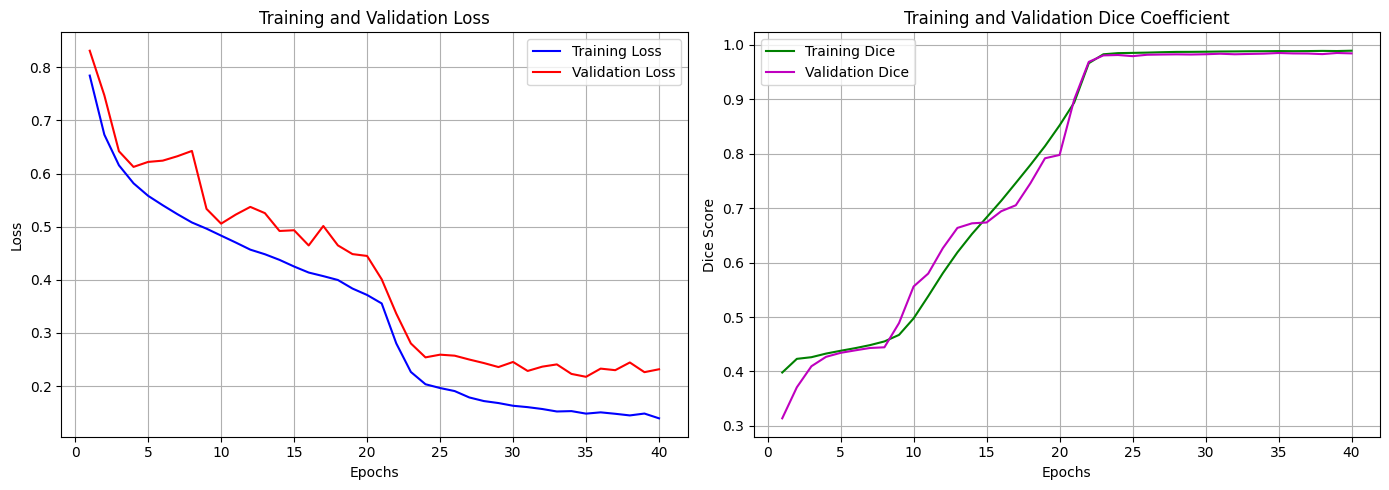

In [40]:
import matplotlib.pyplot as plt

# Extract the metrics that are actually present in your history
epochs = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(14, 5))

# Plot 1: Multi-Class Dice Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['loss'], 'b', label='Training Loss')
plt.plot(epochs, history.history['val_loss'], 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot 2: Dice Coefficient Overlap
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['dice_coefficient'], 'g', label='Training Dice')
plt.plot(epochs, history.history['val_dice_coefficient'], 'm', label='Validation Dice')
plt.title('Training and Validation Dice Coefficient')
plt.xlabel('Epochs')
plt.ylabel('Dice Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

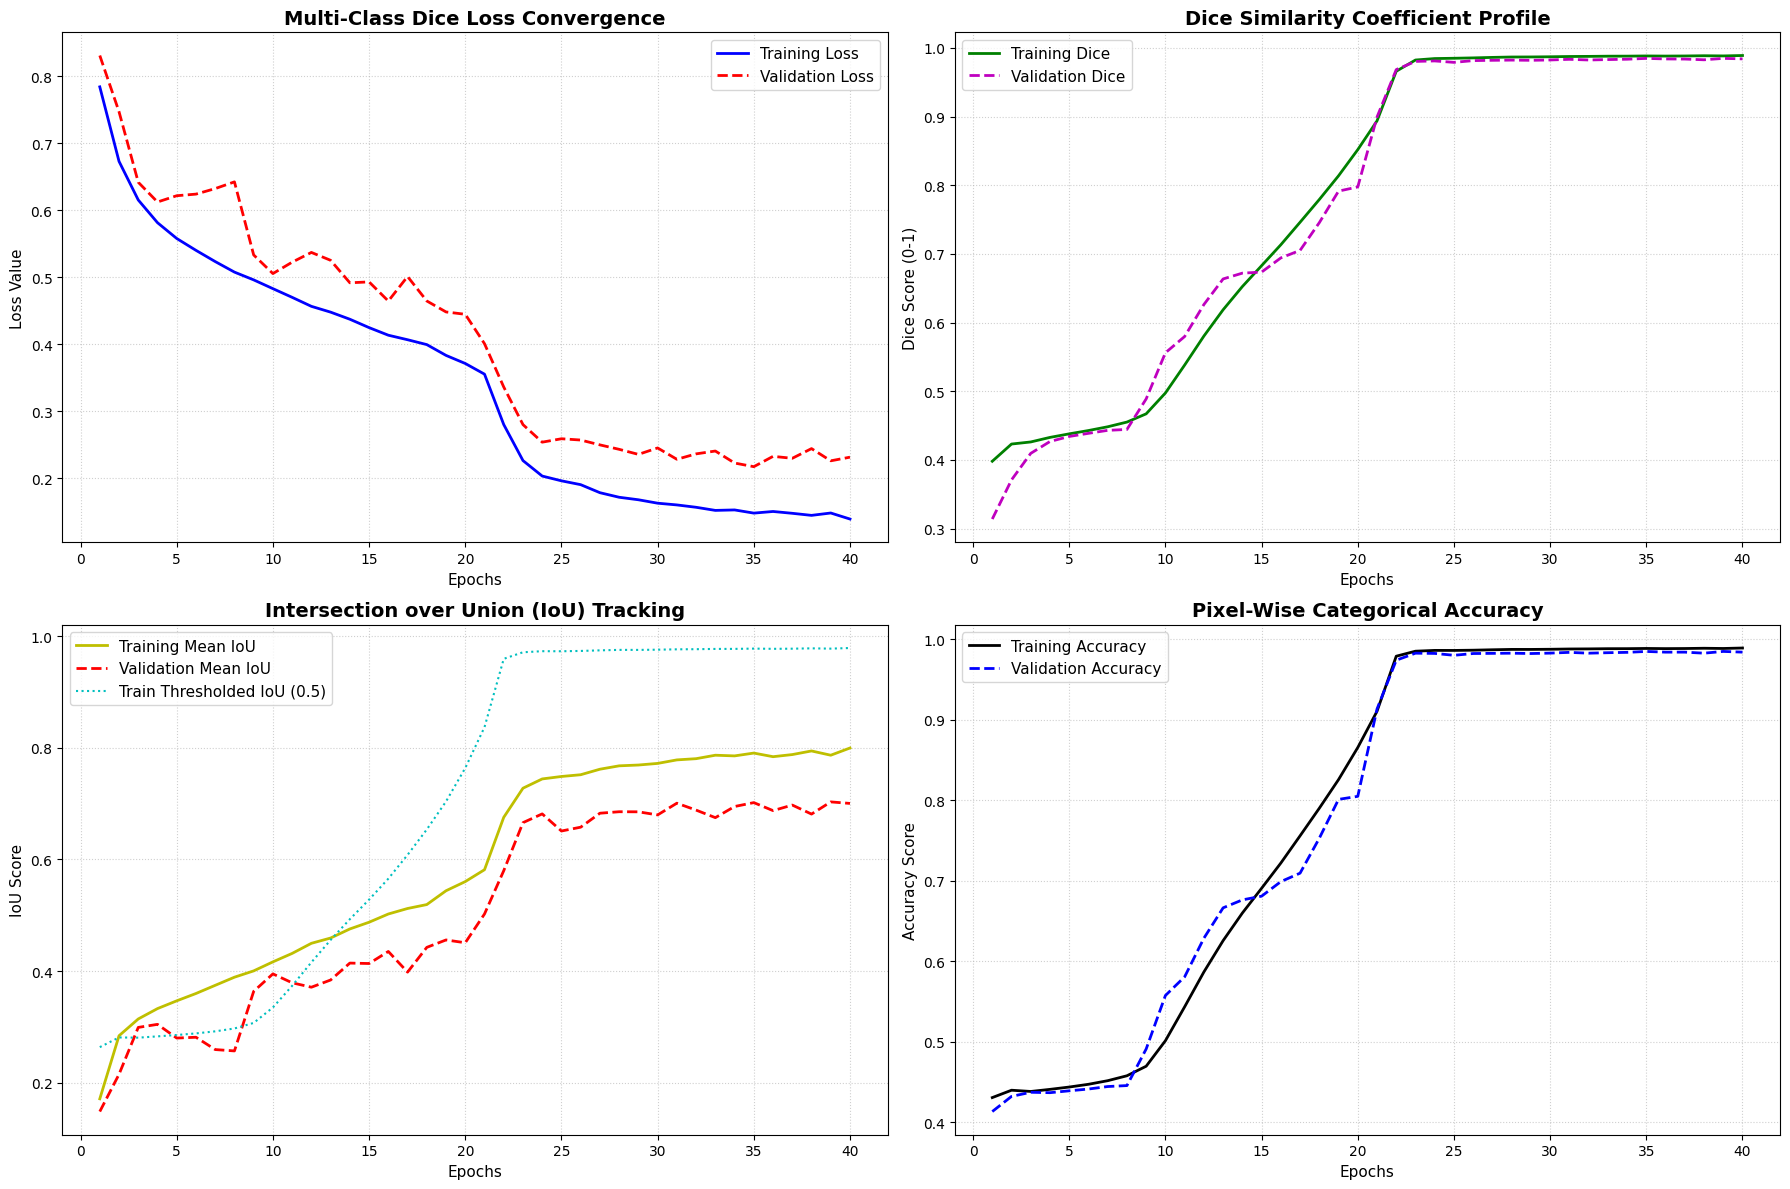

In [42]:
import matplotlib.pyplot as plt

# 1. Dynamically extract the total number of epochs run
epochs = range(1, len(history.history['loss']) + 1)

# 2. Set up a comprehensive 2x2 plotting grid
plt.figure(figsize=(18, 12))

# --- PLOT 1: LOSS CONVERGENCE ---
plt.subplot(2, 2, 1)
plt.plot(epochs, history.history['loss'], 'b-', linewidth=2, label='Training Loss')
plt.plot(epochs, history.history['val_loss'], 'r--', linewidth=2, label='Validation Loss')
plt.title('Multi-Class Dice Loss Convergence', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=11)
plt.ylabel('Loss Value', fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

# --- PLOT 2: DICE COEFFICIENT PERFORMANCE ---
plt.subplot(2, 2, 2)
plt.plot(epochs, history.history['dice_coefficient'], 'g-', linewidth=2, label='Training Dice')
plt.plot(epochs, history.history['val_dice_coefficient'], 'm--', linewidth=2, label='Validation Dice')
plt.title('Dice Similarity Coefficient Profile', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=11)
plt.ylabel('Dice Score (0-1)', fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

# --- PLOT 3: MEAN IOU & THRESHOLDED IOU ---
plt.subplot(2, 2, 3)
plt.plot(epochs, history.history['mean_iou'], 'y-', linewidth=2, label='Training Mean IoU')
plt.plot(epochs, history.history['val_mean_iou'], 'r--', linewidth=2, label='Validation Mean IoU')
plt.plot(epochs, history.history['thresholded_iou_score'], 'c:', linewidth=1.5, label='Train Thresholded IoU (0.5)')
plt.title('Intersection over Union (IoU) Tracking', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=11)
plt.ylabel('IoU Score', fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

# --- PLOT 4: PIXEL ACCURACY COMPARISON ---
plt.subplot(2, 2, 4)
plt.plot(epochs, history.history['accuracy'], 'k-', linewidth=2, label='Training Accuracy')
plt.plot(epochs, history.history['val_accuracy'], 'b--', linewidth=2, label='Validation Accuracy')
plt.title('Pixel-Wise Categorical Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=11)
plt.ylabel('Accuracy Score', fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

# Adjust design padding and render dashboard
plt.tight_layout()
plt.show()

In [41]:
acc = history.history['mean_io_u']
val_acc = history.history['val_mean_io_u']
plt.plot(epochs, acc, 'y', label='Training mean_iou')
plt.plot(epochs, val_acc, 'r', label='Validation mean_iou')
plt.title('Training and validation mean_iou')
plt.xlabel('Epochs')
plt.ylabel('mean_iou')
plt.legend()
plt.show()

KeyError: 'mean_io_u'

In [43]:
acc = history.history['iou_score']
val_acc = history.history['val_iou_score']

plt.plot(epochs, acc, 'y', label='Training iou_score')
plt.plot(epochs, val_acc, 'r', label='Validation iou_score')
plt.title('Training and validation iou_score')
plt.xlabel('Epochs')
plt.ylabel('iou_score')
plt.legend()
plt.show()

KeyError: 'iou_score'

In [49]:
import tensorflow as tf
from tensorflow.keras.utils import get_custom_objects
from tensorflow.keras.models import load_model

# Update the global Keras registry with the exact string keys your model files expect
get_custom_objects().update({
    # 1. Map legacy loss keys to our native multi-class dice loss function
    "dice_loss": multi_class_dice_loss,
    "multi_class_dice_loss": multi_class_dice_loss,
    "dice_coefficient": dice_coefficient,
    
    # 2. Map the legacy 'sm' IoU key to our safe, native thresholded function
    "iou_score": thresholded_iou_score,
    "iou_coefficient": iou_coefficient,
    "thresholded_iou_score": thresholded_iou_score,
    
    # 3. Map the mean IoU keys to our one-hot safe CleanMeanIoU class wrapper
    "mean_iou_score": CleanMeanIoU(num_classes=4),
    "mean_iou": CleanMeanIoU(num_classes=4)
})

print("Global Keras custom object registry updated successfully!")

Global Keras custom object registry updated successfully!


In [50]:
import tensorflow as tf
from tensorflow.keras.models import load_model

print("Loading model structure and weights... Please wait.")

# 1. Safe load without compiling to prevent legacy config crashes
my_model = load_model(
    '/kaggle/working/best_resunet3d_model.keras', 
    compile=False
)

# 2. Re-compile to arm your full 8-metric tracking suite for testing/inference
my_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=multi_class_dice_loss,
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name='accuracy'), 
        CleanMeanIoU(num_classes=4, name='mean_iou'), 
        thresholded_iou_score, 
        dice_coefficient,
        iou_coefficient,
        precision_metric,
        recall_metric,
        specificity_metric
    ]
)

print("\n" + "="*45)
print(" SUCCESS: ResUNet3D fully loaded and compiled!")
print("="*45)

Loading model structure and weights... Please wait.

 SUCCESS: ResUNet3D fully loaded and compiled!


In [67]:
img_num = 167

test_img = np.load("/kaggle/input/brats701515/input_data_128/test/images/image_"+str(img_num)+".npy")

test_mask = np.load("/kaggle/input/brats701515/input_data_128/test/masks/mask_"+str(img_num)+".npy")
test_mask_argmax=np.argmax(test_mask, axis=3)

test_img_input = np.expand_dims(test_img, axis=0)
test_prediction = my_model.predict(test_img_input)
test_prediction_argmax=np.argmax(test_prediction, axis=4)[0,:,:,:]


print(test_prediction_argmax.shape)
print(test_mask_argmax.shape)
print(np.unique(test_mask_argmax))
print(np.unique(test_prediction_argmax))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]


55


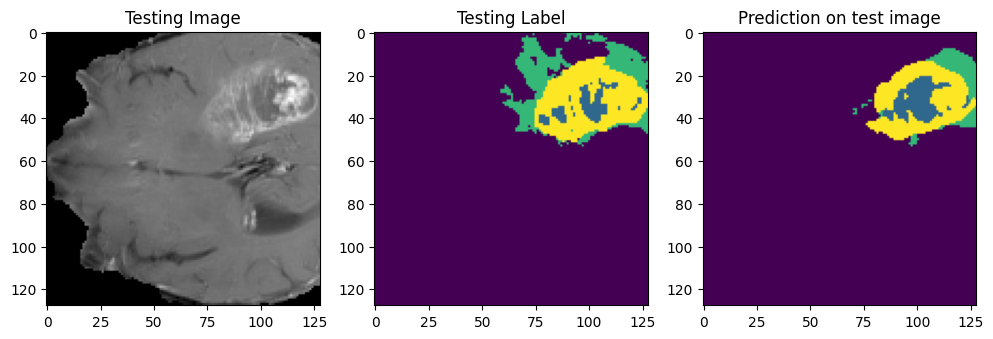

In [68]:
from matplotlib import pyplot as plt
import random

n_slice=random.randint(0, test_prediction_argmax.shape[2])
n_slice = 55
print(n_slice)
plt.figure(figsize=(12, 8))
plt.subplot(231)
plt.title('Testing Image')
plt.imshow(test_img[:,:,n_slice,1], cmap='gray')
plt.subplot(232)
plt.title('Testing Label')
plt.imshow(test_mask_argmax[:,:,n_slice])
plt.subplot(233)
plt.title('Prediction on test image')
plt.imshow(test_prediction_argmax[:,:, n_slice])
plt.show()

In [70]:
import os
import re

dir_path = "/kaggle/input/brats701515/input_data_128/test/images/"
lnum=[]
for filename in sorted(os.listdir(dir_path)):
    if os.path.isfile(os.path.join(dir_path, filename)):
        name_without_ext, _ = os.path.splitext(filename)
        
        # Regex looks for one or more digits (\d+) right at the end of the filename
        match = re.search(r'(\d+)$', name_without_ext)
        
        if match:
            full_number = match.group(1)
            print(f"File: {filename:<20} -> Full File ID: {full_number}")
            lnum.append(full_number)

File: image_100.npy        -> Full File ID: 100
File: image_110.npy        -> Full File ID: 110
File: image_111.npy        -> Full File ID: 111
File: image_113.npy        -> Full File ID: 113
File: image_114.npy        -> Full File ID: 114
File: image_12.npy         -> Full File ID: 12
File: image_137.npy        -> Full File ID: 137
File: image_142.npy        -> Full File ID: 142
File: image_145.npy        -> Full File ID: 145
File: image_147.npy        -> Full File ID: 147
File: image_15.npy         -> Full File ID: 15
File: image_154.npy        -> Full File ID: 154
File: image_16.npy         -> Full File ID: 16
File: image_167.npy        -> Full File ID: 167
File: image_174.npy        -> Full File ID: 174
File: image_177.npy        -> Full File ID: 177
File: image_192.npy        -> Full File ID: 192
File: image_195.npy        -> Full File ID: 195
File: image_202.npy        -> Full File ID: 202
File: image_204.npy        -> Full File ID: 204
File: image_205.npy        -> Full File ID:

In [71]:
lnum

['100',
 '110',
 '111',
 '113',
 '114',
 '12',
 '137',
 '142',
 '145',
 '147',
 '15',
 '154',
 '16',
 '167',
 '174',
 '177',
 '192',
 '195',
 '202',
 '204',
 '205',
 '207',
 '211',
 '218',
 '227',
 '231',
 '234',
 '241',
 '261',
 '263',
 '265',
 '273',
 '275',
 '283',
 '284',
 '301',
 '303',
 '317',
 '322',
 '345',
 '360',
 '365',
 '368',
 '41',
 '55',
 '56',
 '63',
 '70',
 '82',
 '84',
 '88',
 '90',
 '91']

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


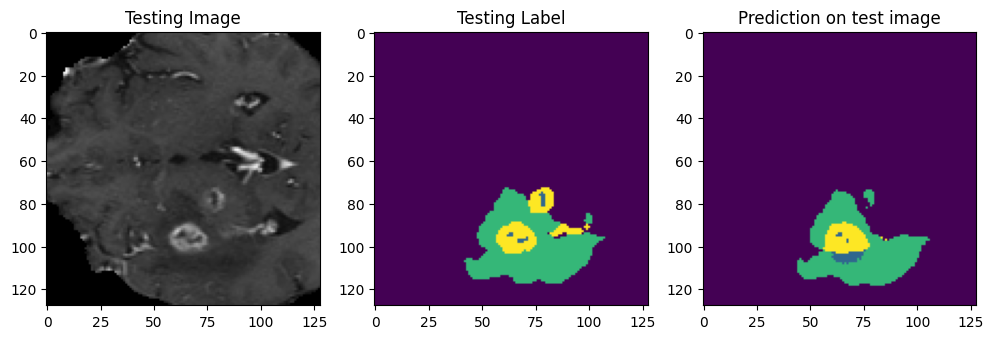

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


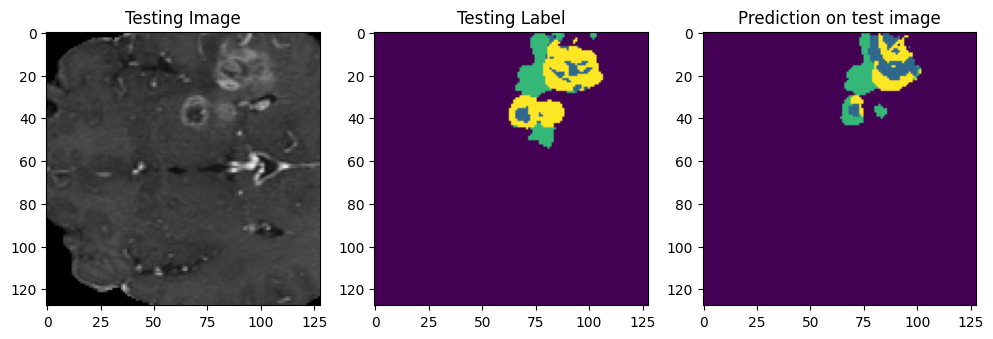

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


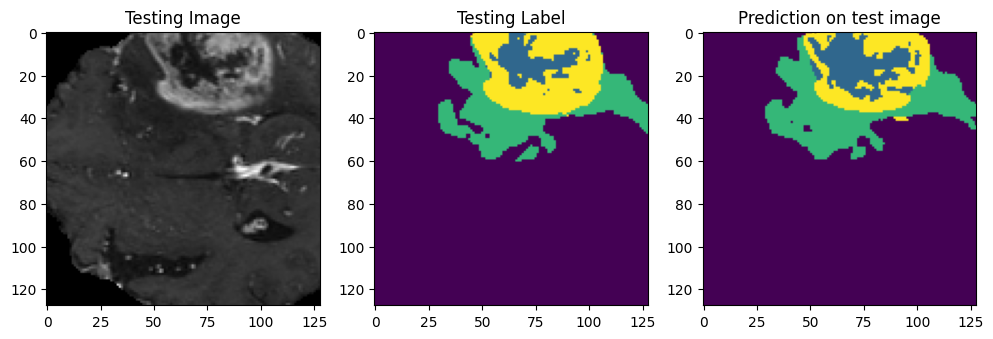

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


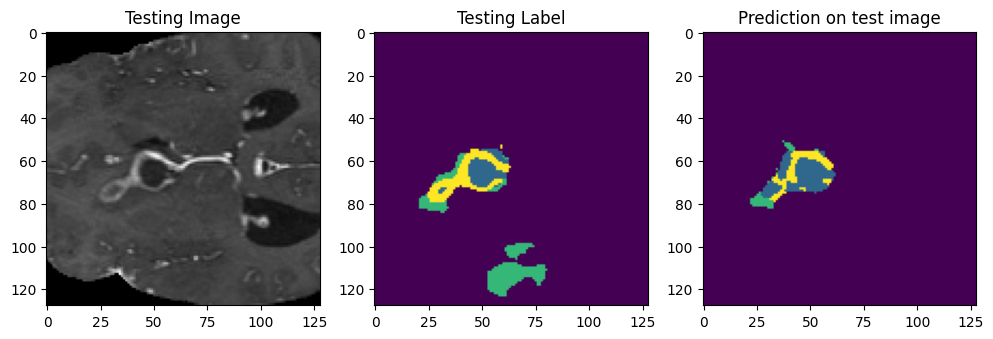

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


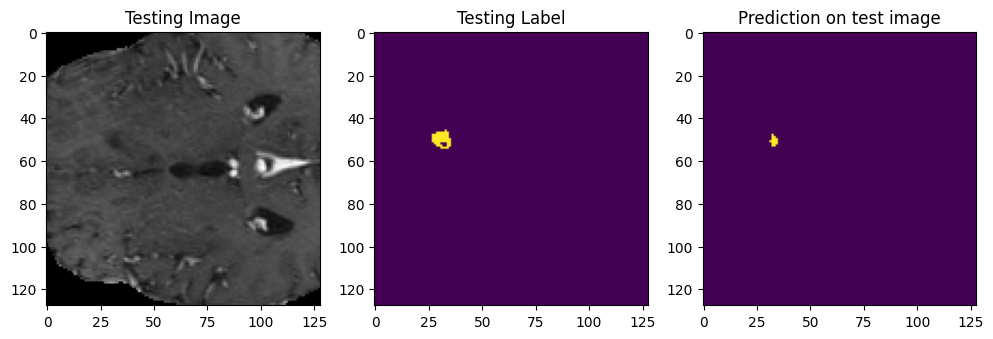

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


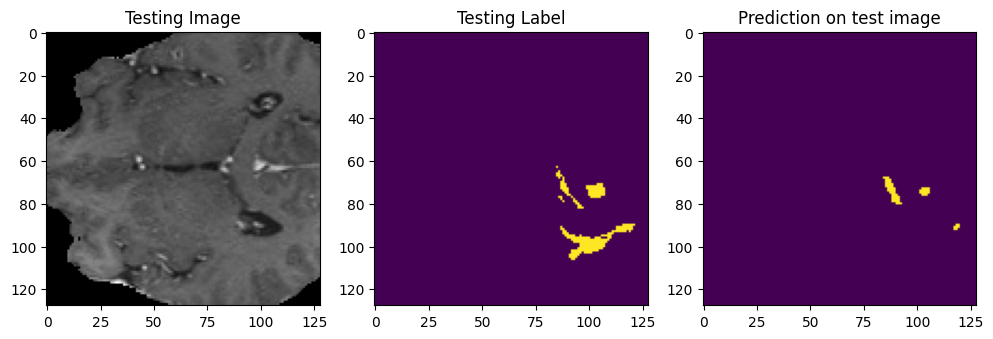

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


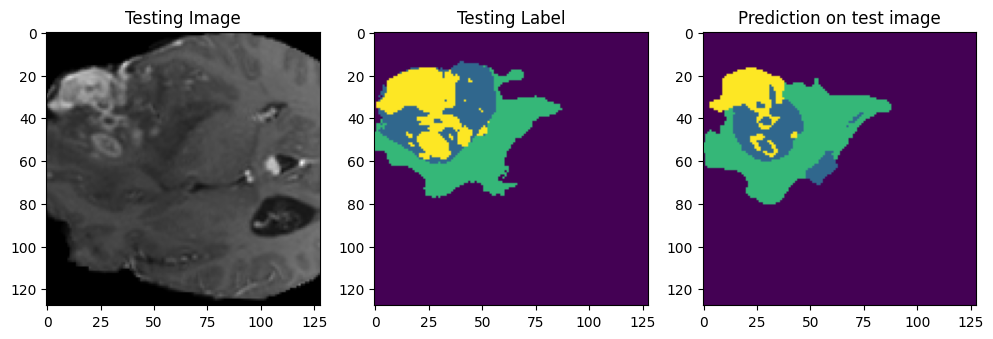

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


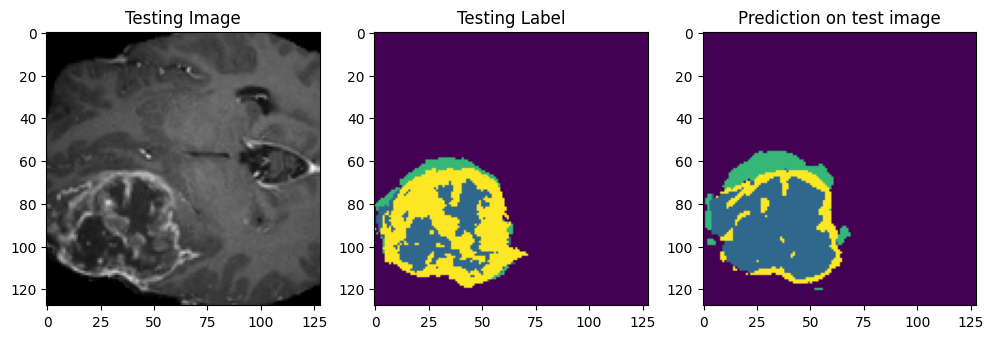

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


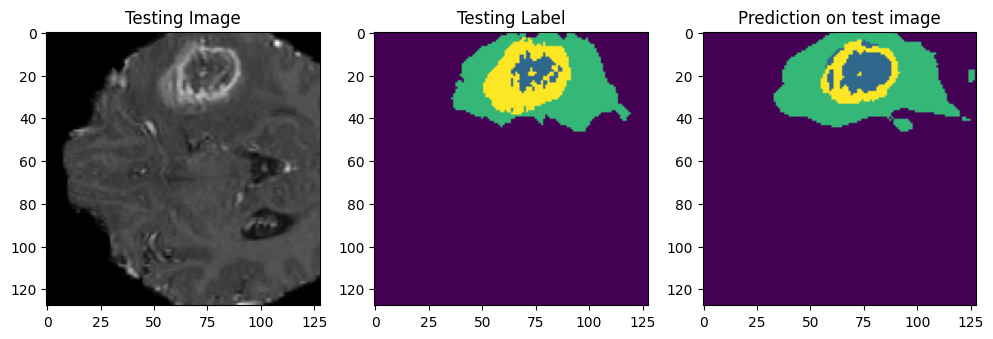

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


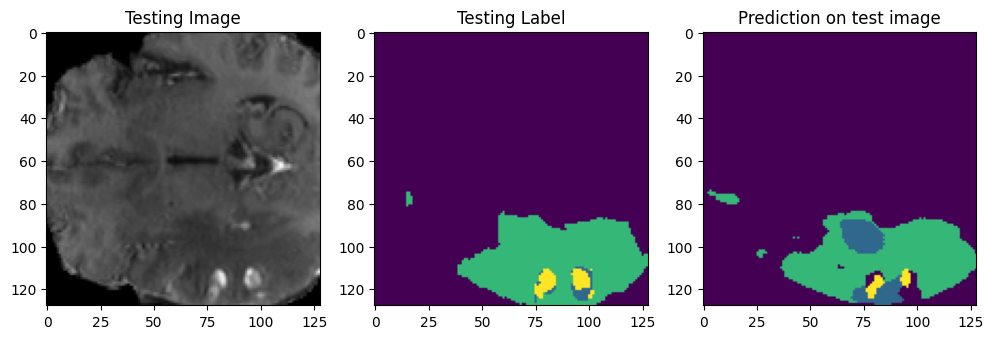

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


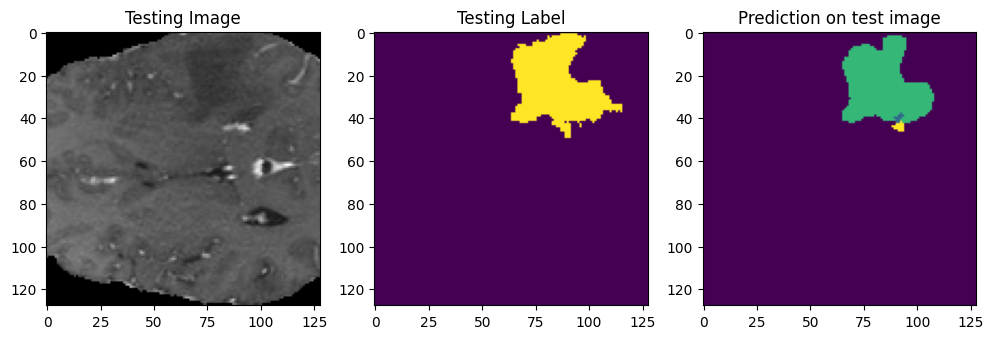

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


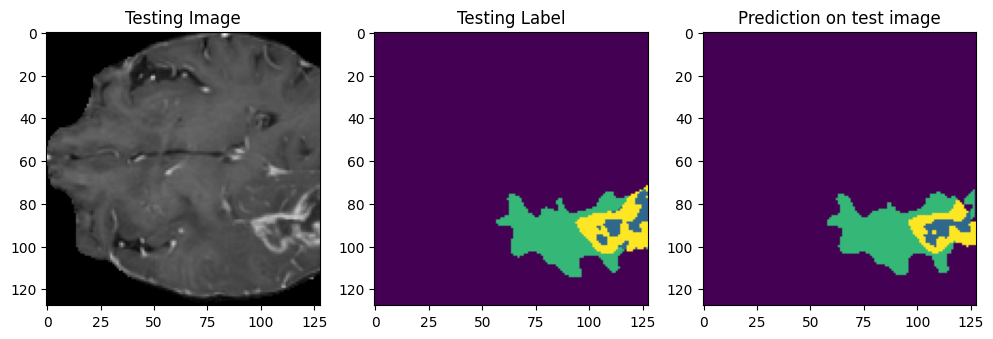

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


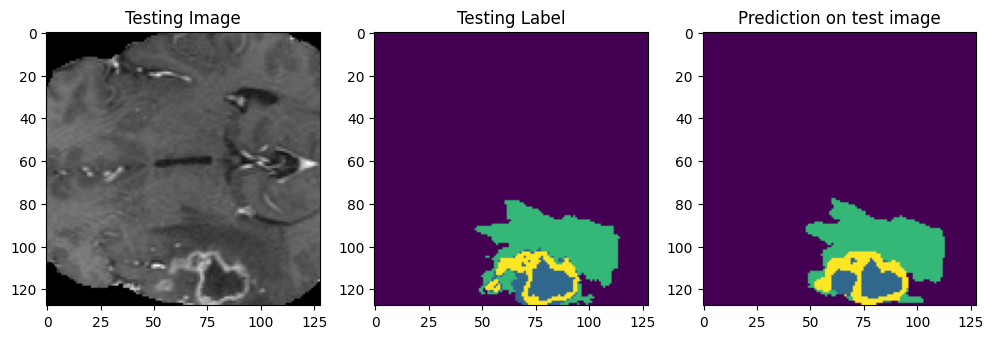

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


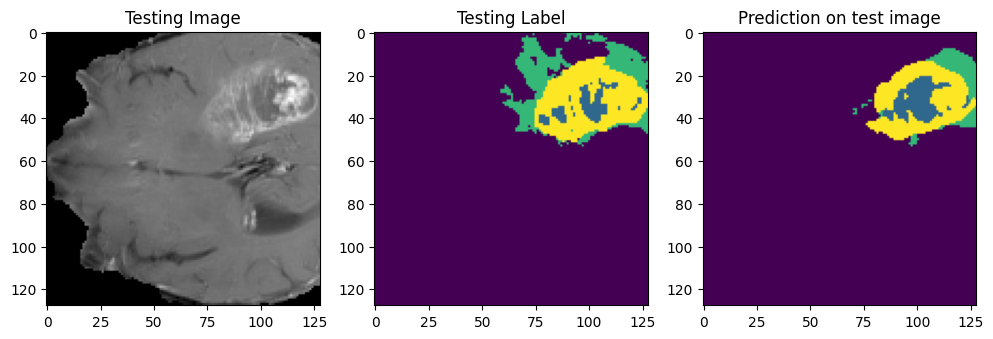

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


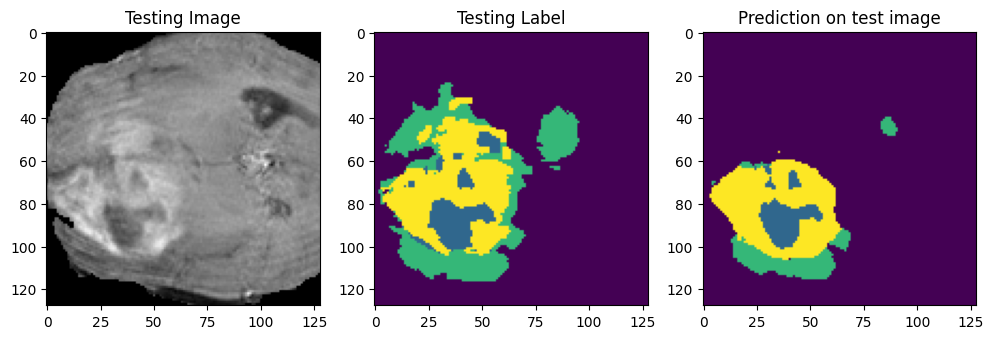

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


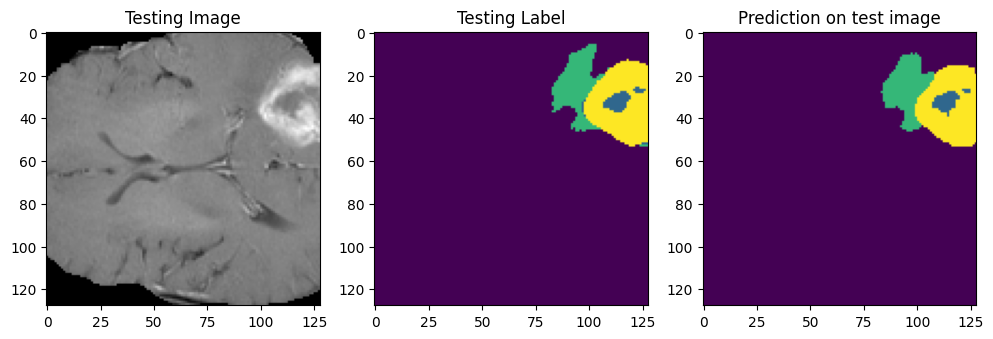

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


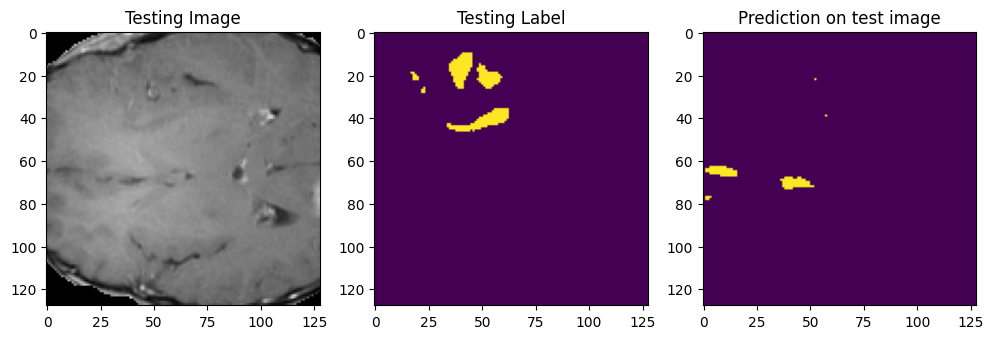

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


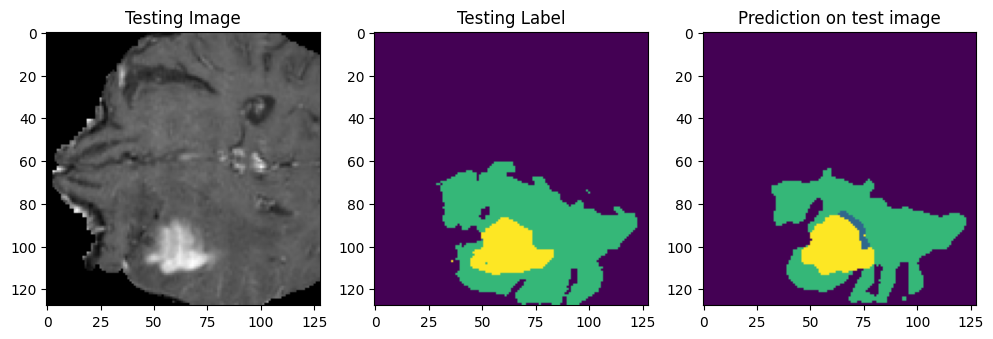

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


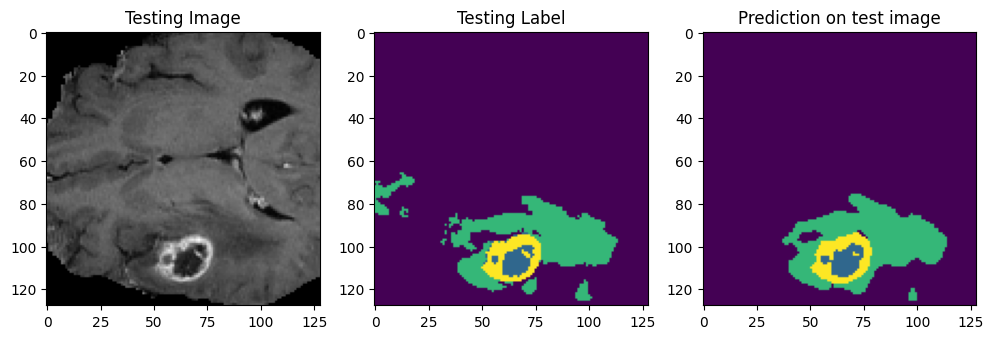

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


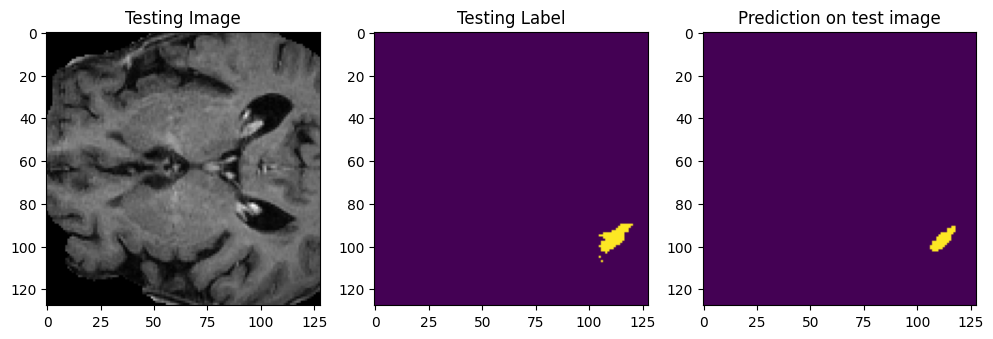

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


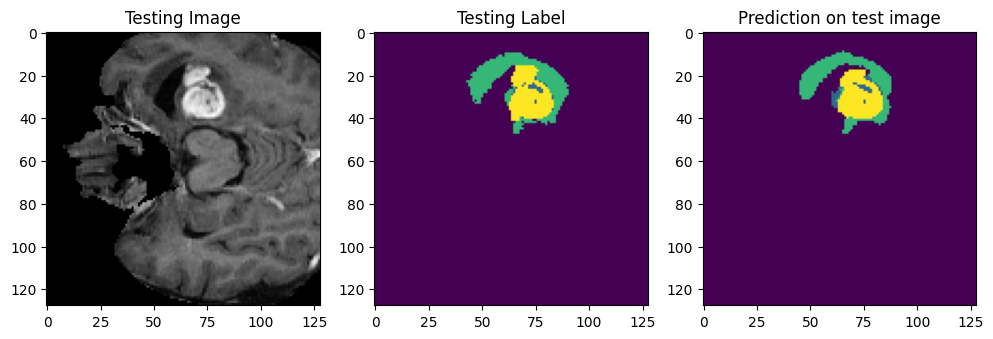

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


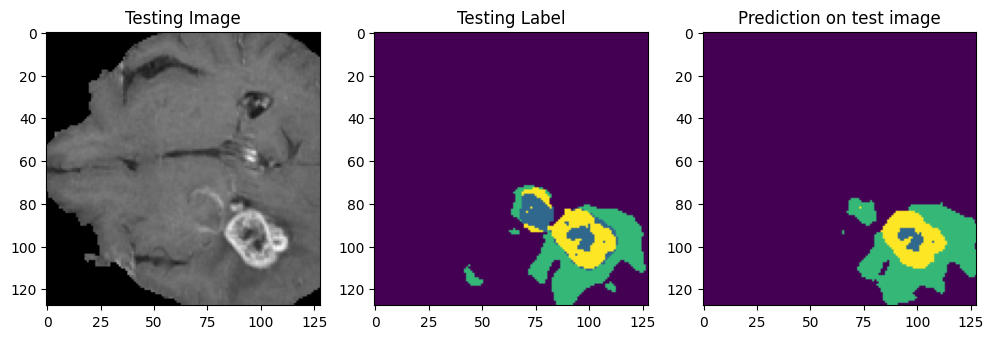

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


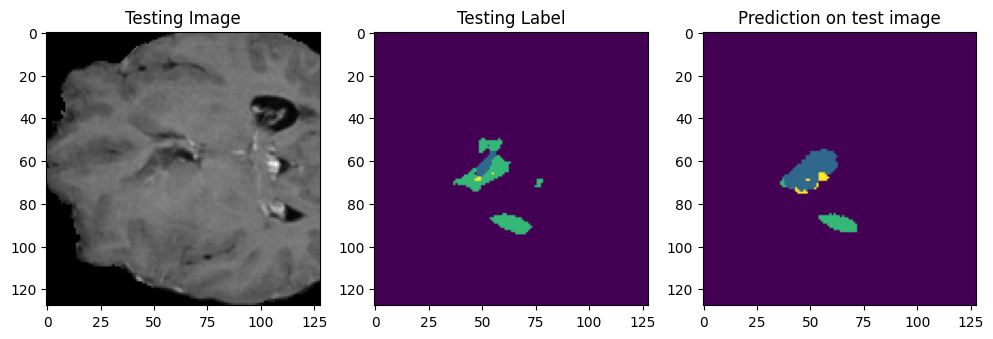

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


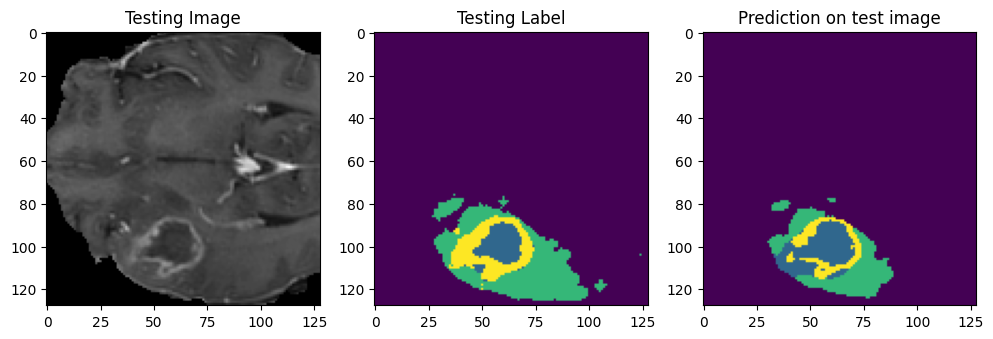

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


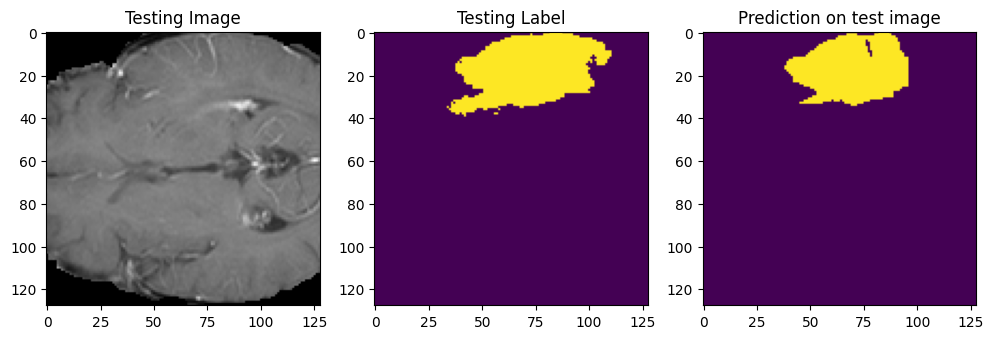

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


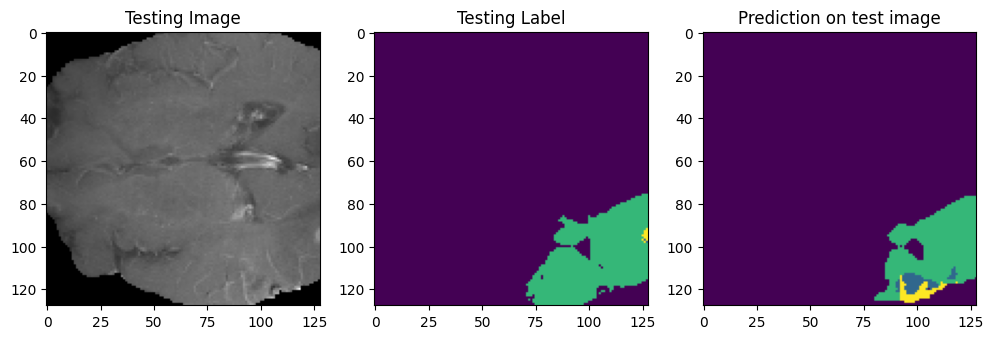

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


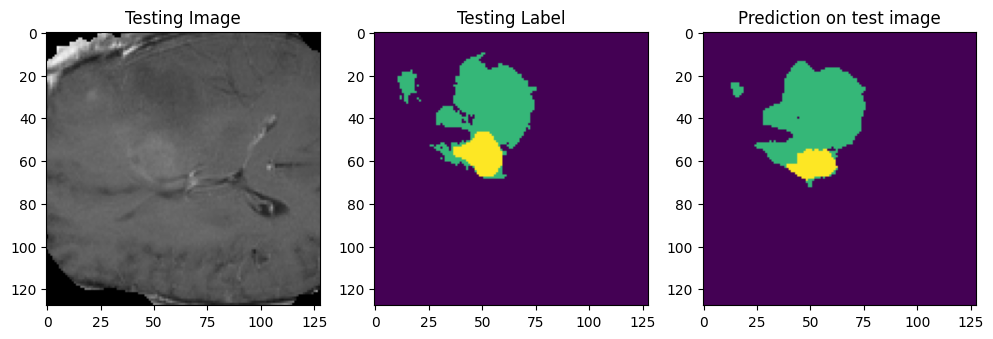

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


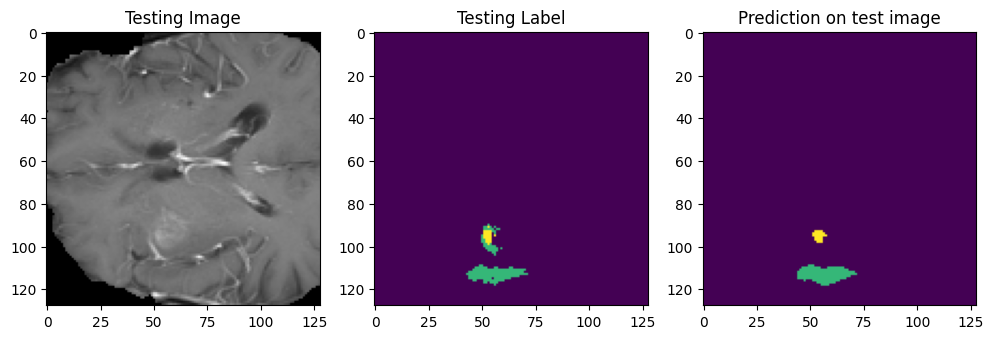

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2]
[0 1 2 3]
55


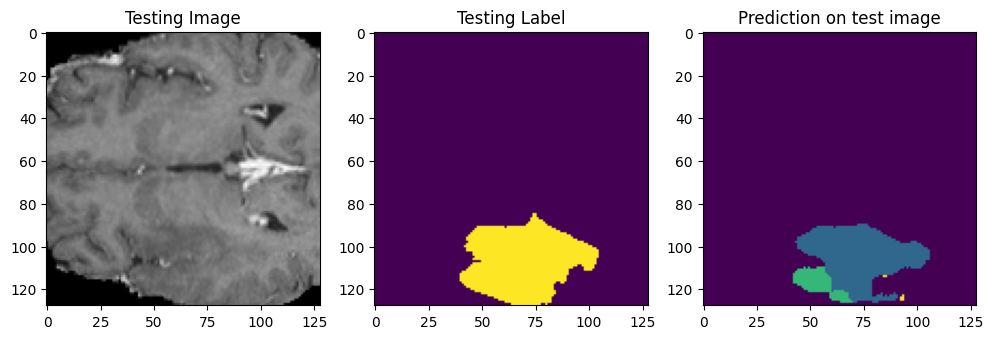

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2]
[0 1 2 3]
55


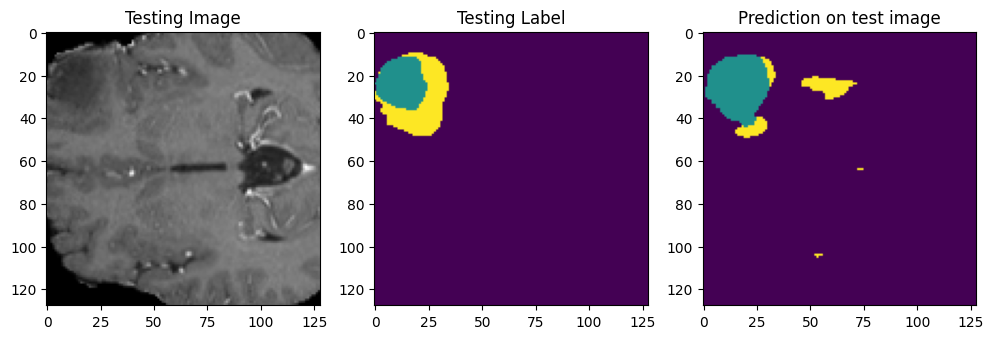

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2]
[0 1 2 3]
55


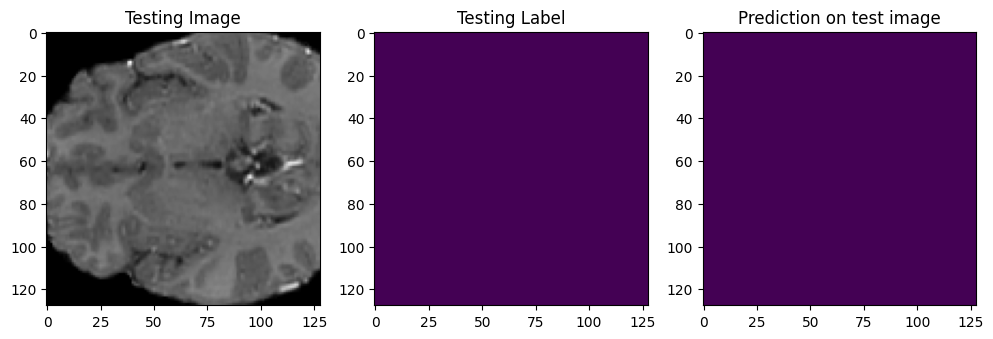

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


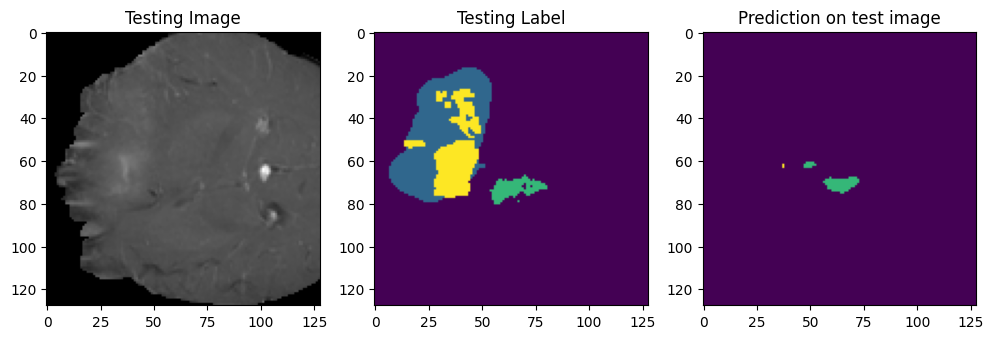

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


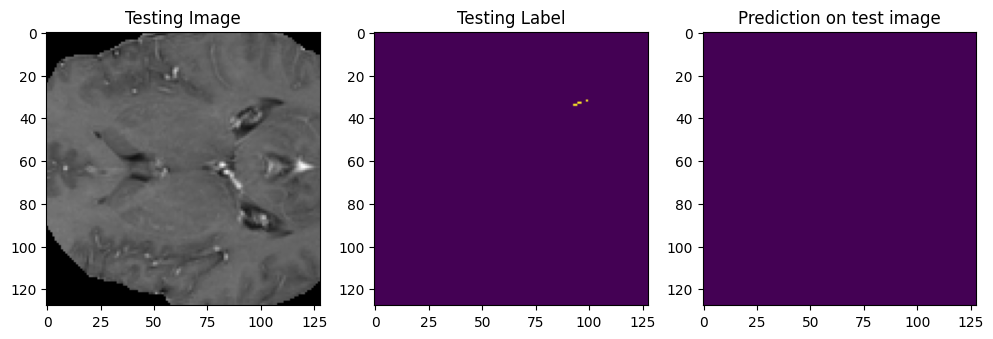

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


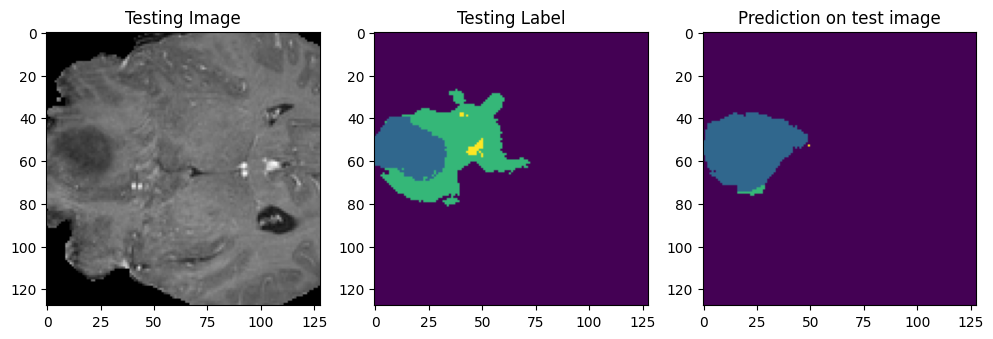

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


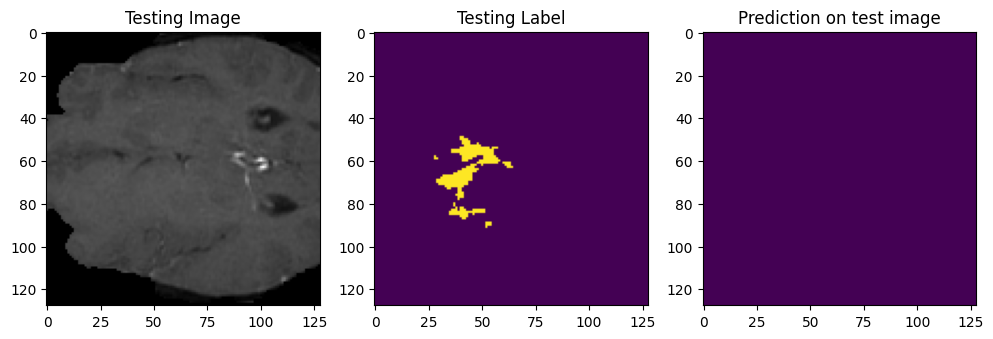

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


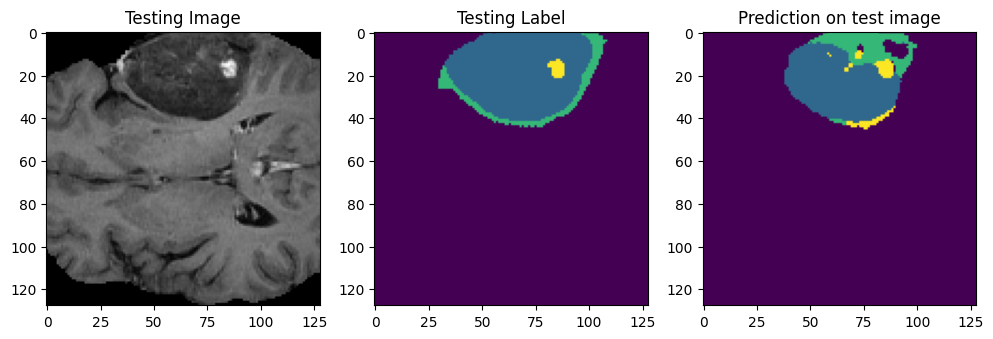

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2]
[0 1 2]
55


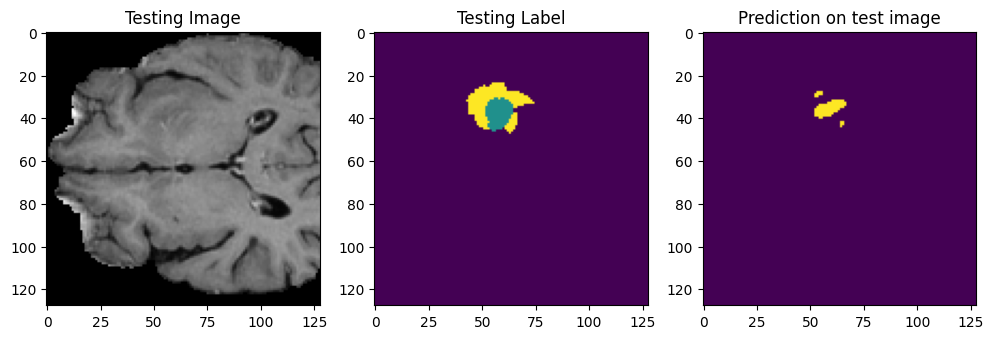

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


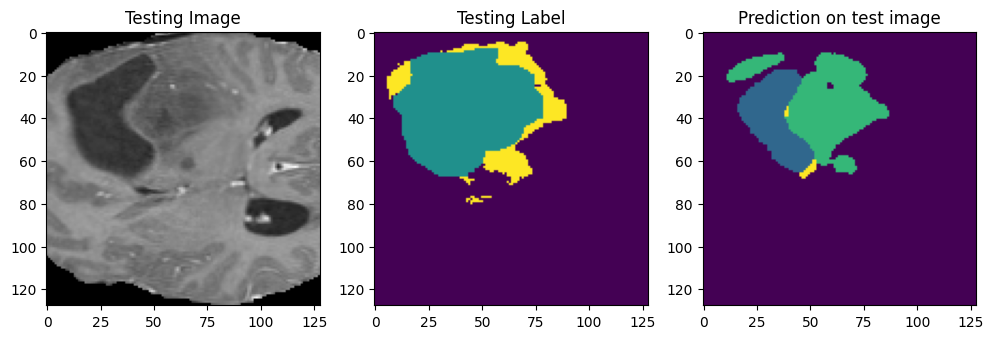

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


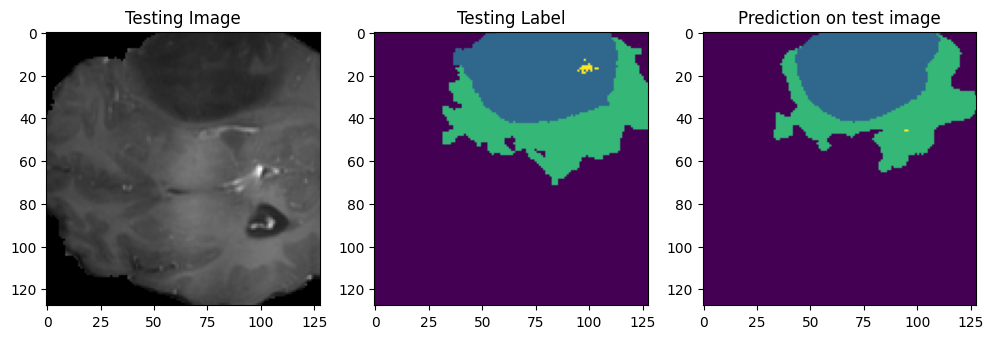

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


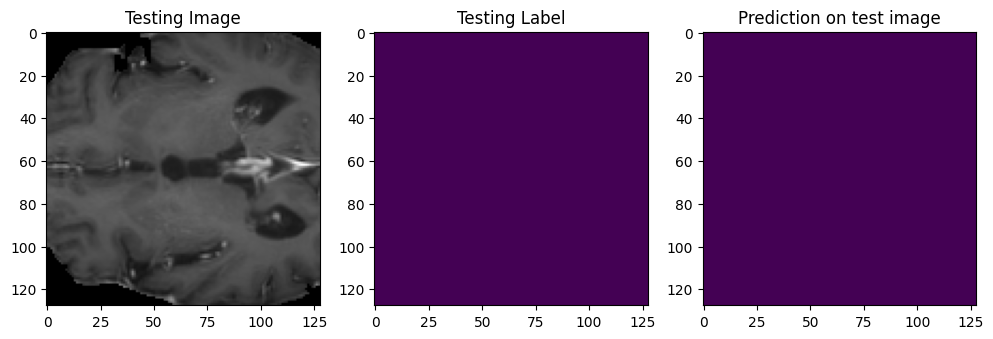

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


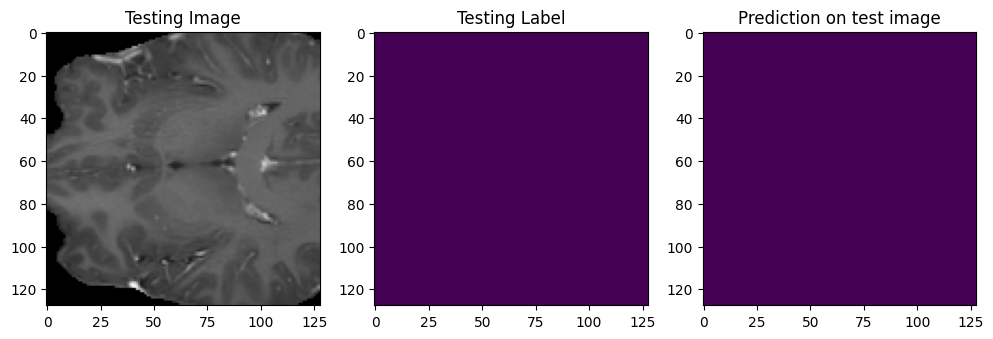

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


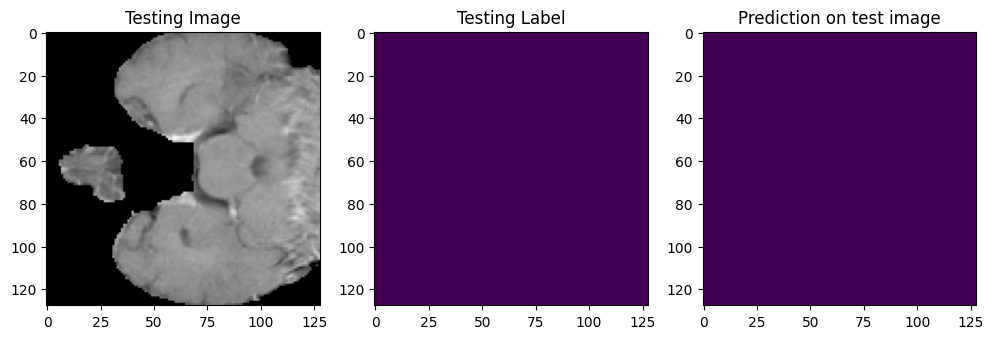

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


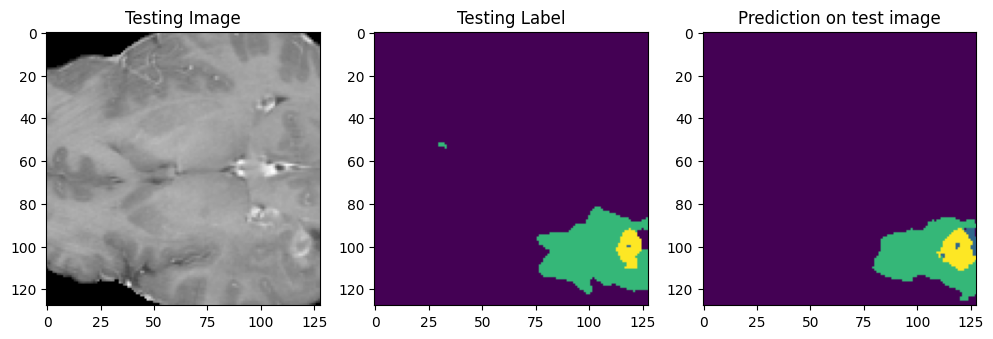

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


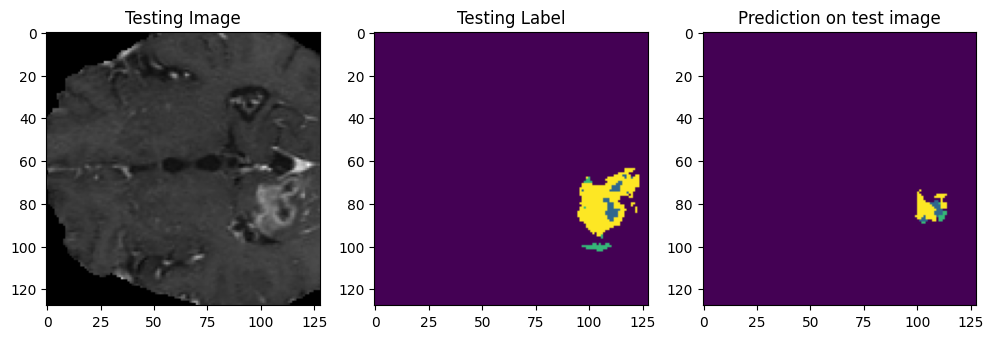

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


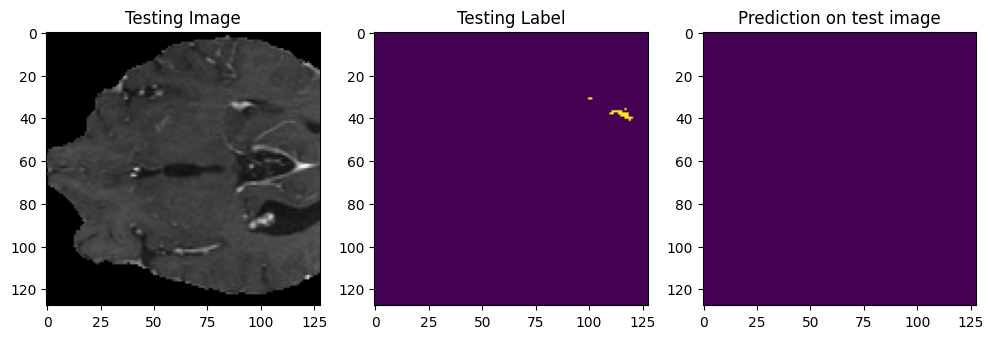

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


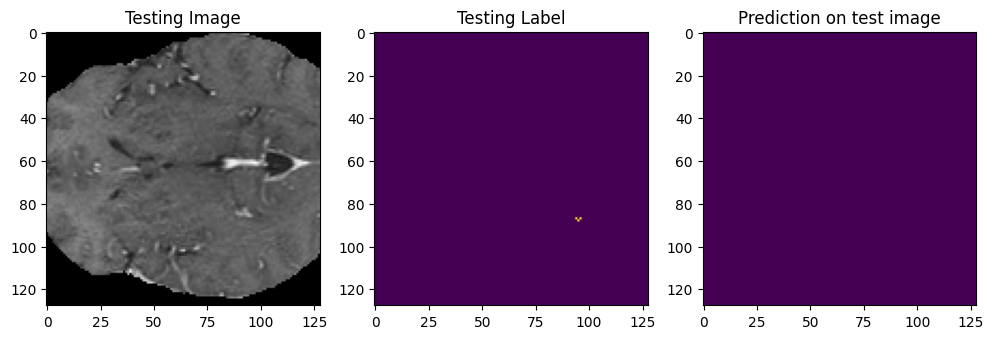

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


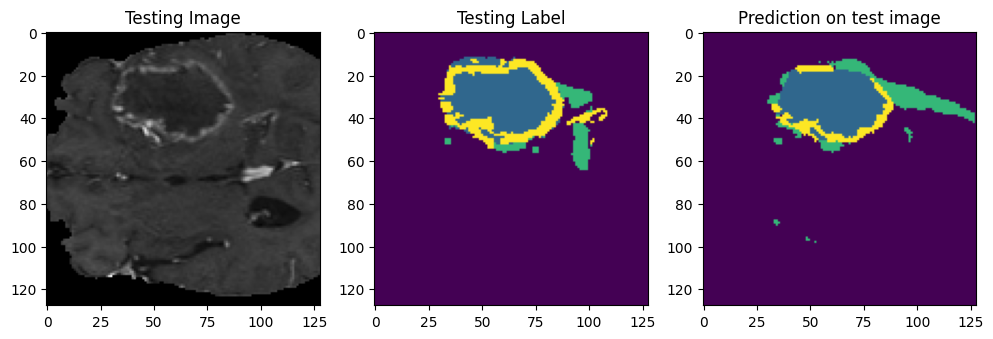

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


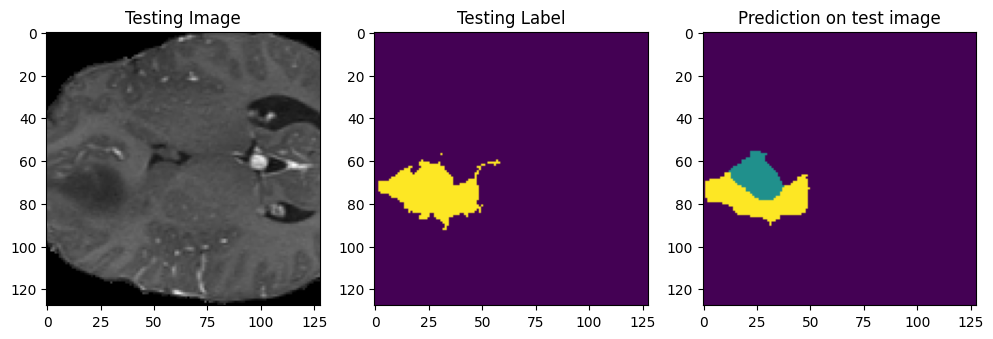

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


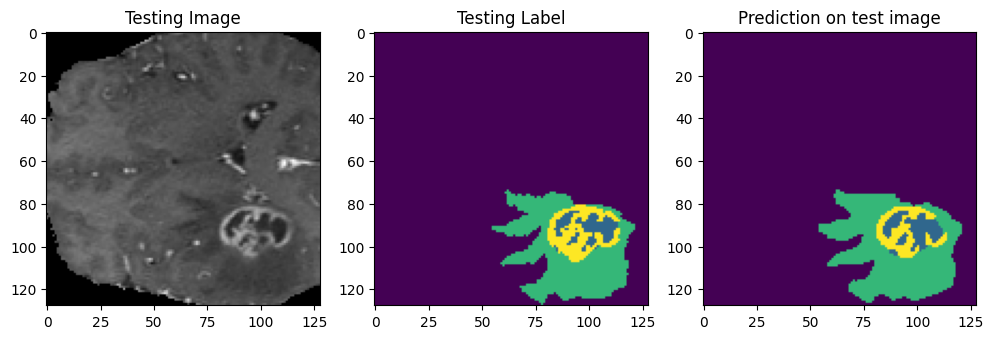

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
(128, 128, 128)
(128, 128, 128)
[0 1 2 3]
[0 1 2 3]
55


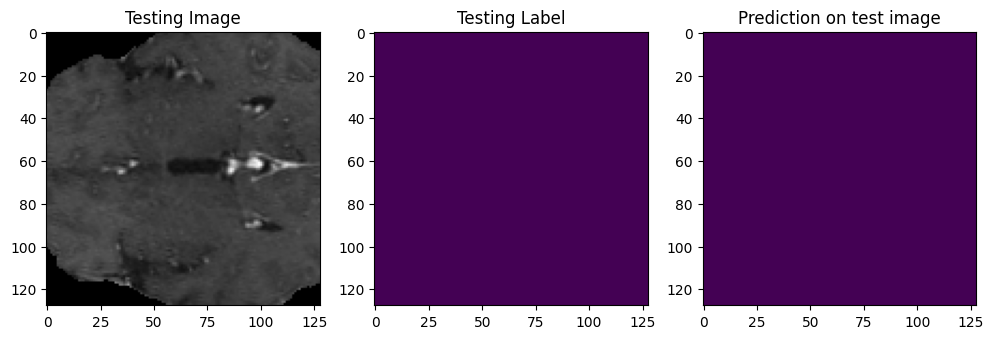

In [75]:
cn=50
for i in lnum:
    img_num = i

    test_img = np.load("/kaggle/input/brats701515/input_data_128/test/images/image_"+img_num+".npy")
    
    test_mask = np.load("/kaggle/input/brats701515/input_data_128/test/masks/mask_"+img_num+".npy")
    test_mask_argmax=np.argmax(test_mask, axis=3)
    
    test_img_input = np.expand_dims(test_img, axis=0)
    test_prediction = my_model.predict(test_img_input)
    test_prediction_argmax=np.argmax(test_prediction, axis=4)[0,:,:,:]
    
    
    print(test_prediction_argmax.shape)
    print(test_mask_argmax.shape)
    print(np.unique(test_mask_argmax))
    print(np.unique(test_prediction_argmax))
    #n_slice=random.randint(0, test_prediction_argmax.shape[2])
    n_slice = 55
    print(n_slice)
    plt.figure(figsize=(12, 8))
    plt.subplot(231)
    plt.title('Testing Image')
    plt.imshow(test_img[:,:,n_slice,1], cmap='gray')
    plt.subplot(232)
    plt.title('Testing Label')
    plt.imshow(test_mask_argmax[:,:,n_slice])
    plt.subplot(233)
    plt.title('Prediction on test image')
    plt.imshow(test_prediction_argmax[:,:, n_slice])
    plt.show()
    cn=cn-1
    if (cn==0): break